# 🏋️ PLAYHACK / ML PS — Advanced Exploratory Data Analysis

**Objective**: Predict whether an athlete will be injured in the next 30 days (risk window), and if so, estimate the onset day and recovery duration.

| Task | Target | Type |
|------|--------|------|
| A | `injured_in_risk_window` | Binary Classification (F1) |
| B | `onset_day_offset` & `recovery_duration` | Regression (MAE → Skill Score) |

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


---
## 📁 1. Data Loading & Initial Inspection
---

In [2]:
# Load all datasets
athlete_meta = pd.read_csv('athlete_metadata.csv')
train_labels = pd.read_csv('train_labels.csv')
daily_activity = pd.read_csv('dailyActivity_merged.csv')
training_sessions = pd.read_csv('training_sessions.csv')
sleep = pd.read_csv('sleepDay_merged.csv')
weight = pd.read_csv('weightLogInfo_merged.csv')

# Hourly data — large files, load with optimized dtypes
hourly_calories = pd.read_csv('hourlyCalories_merged.csv')
hourly_heartrate = pd.read_csv('hourlyHeartrate_merged.csv')
hourly_intensity = pd.read_csv('hourlyIntensities_merged.csv')
hourly_steps = pd.read_csv('hourlySteps_merged.csv')

datasets = {
    'athlete_metadata': athlete_meta,
    'train_labels': train_labels,
    'dailyActivity': daily_activity,
    'training_sessions': training_sessions,
    'sleepDay': sleep,
    'weightLogInfo': weight,
    'hourlyCalories': hourly_calories,
    'hourlyHeartrate': hourly_heartrate,
    'hourlyIntensities': hourly_intensity,
    'hourlySteps': hourly_steps
}

print('📊 Dataset Shapes Overview:')
print('=' * 50)
for name, df in datasets.items():
    mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f'{name:25s} → {str(df.shape):15s} | {mem:.1f} MB')

📊 Dataset Shapes Overview:
athlete_metadata          → (3000, 11)      | 0.9 MB
train_labels              → (3000, 4)       | 0.1 MB
dailyActivity             → (180000, 10)    | 22.5 MB
training_sessions         → (112108, 6)     | 21.0 MB
sleepDay                  → (180000, 5)     | 15.6 MB
weightLogInfo             → (7452, 6)       | 0.7 MB
hourlyCalories            → (4104334, 3)    | 332.4 MB
hourlyHeartrate           → (4104334, 5)    | 391.4 MB
hourlyIntensities         → (4104334, 4)    | 363.8 MB
hourlySteps               → (4104334, 3)    | 332.4 MB


In [3]:
# Detailed info for each dataset
for name, df in datasets.items():
    print(f'\n{"="*60}')
    print(f'📌 {name.upper()}')
    print(f'{"="*60}')
    print(f'Shape: {df.shape}')
    print(f'\nColumn Types:')
    print(df.dtypes)
    print(f'\nMissing Values:')
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(missing[missing > 0])
    else:
        print('  None!')
    print(f'\nFirst 3 rows:')
    display(df.head(3))


📌 ATHLETE_METADATA
Shape: (3000, 11)

Column Types:
athlete_id                     int64
sport                            str
age                            int64
gender                           str
height_cm                    float64
weight_kg_baseline           float64
dominant_side                    str
years_playing                  int64
position                         str
team_id                          str
prior_season_injury_count      int64
dtype: object

Missing Values:
  None!

First 3 rows:


,athlete_id,sport,age,gender,height_cm,weight_kg_baseline,dominant_side,years_playing,position,team_id,prior_season_injury_count
0,1,Football,24,male,183.0,74.0,right,5,Goalkeeper,FOO-3,1
1,2,Athletics,20,female,165.3,56.0,right,6,Throws,ATH-2,1
2,3,Tennis,18,male,186.1,50.4,right,5,Singles,TEN-5,1



📌 TRAIN_LABELS
Shape: (3000, 4)

Column Types:
athlete_id                  int64
injured_in_risk_window      int64
onset_day_offset          float64
recovery_duration         float64
dtype: object

Missing Values:
onset_day_offset     1950
recovery_duration    1950
dtype: int64

First 3 rows:


,athlete_id,injured_in_risk_window,onset_day_offset,recovery_duration
0,1,0,NaN,NaN
1,2,1,23.0,10.0
2,3,0,NaN,NaN



📌 DAILYACTIVITY
Shape: (180000, 10)

Column Types:
Id                        int64
ActivityDate                str
TotalSteps                int64
TotalDistance           float64
TrackerDistance         float64
VeryActiveMinutes         int64
FairlyActiveMinutes       int64
LightlyActiveMinutes      int64
SedentaryMinutes          int64
Calories                  int64
dtype: object

Missing Values:
  None!

First 3 rows:


...

,Id,ActivityHour,AvgHeartRate,MinHeartRate,MaxHeartRate
0,1,2026-01-05T00:00:00,73,69,80
1,1,2026-01-05T01:00:00,67,65,77
2,1,2026-01-05T02:00:00,66,64,74



📌 HOURLYINTENSITIES
Shape: (4104334, 4)

Column Types:
Id                    int64
ActivityHour            str
TotalIntensity        int64
AverageIntensity    float64
dtype: object

Missing Values:
  None!

First 3 rows:


,Id,ActivityHour,TotalIntensity,AverageIntensity
0,1,1/5/2026 12:00:00 AM,1,0.01
1,1,1/5/2026 1:00:00 AM,0,0.00
2,1,1/5/2026 2:00:00 AM,0,0.00



📌 HOURLYSTEPS
Shape: (4104334, 3)

Column Types:
Id              int64
ActivityHour      str
StepTotal       int64
dtype: object

Missing Values:
  None!

First 3 rows:


,Id,ActivityHour,StepTotal
0,1,1/5/2026 12:00:00 AM,52
1,1,1/5/2026 1:00:00 AM,37
2,1,1/5/2026 2:00:00 AM,10


---
## 🎯 2. Target Variable Analysis
---

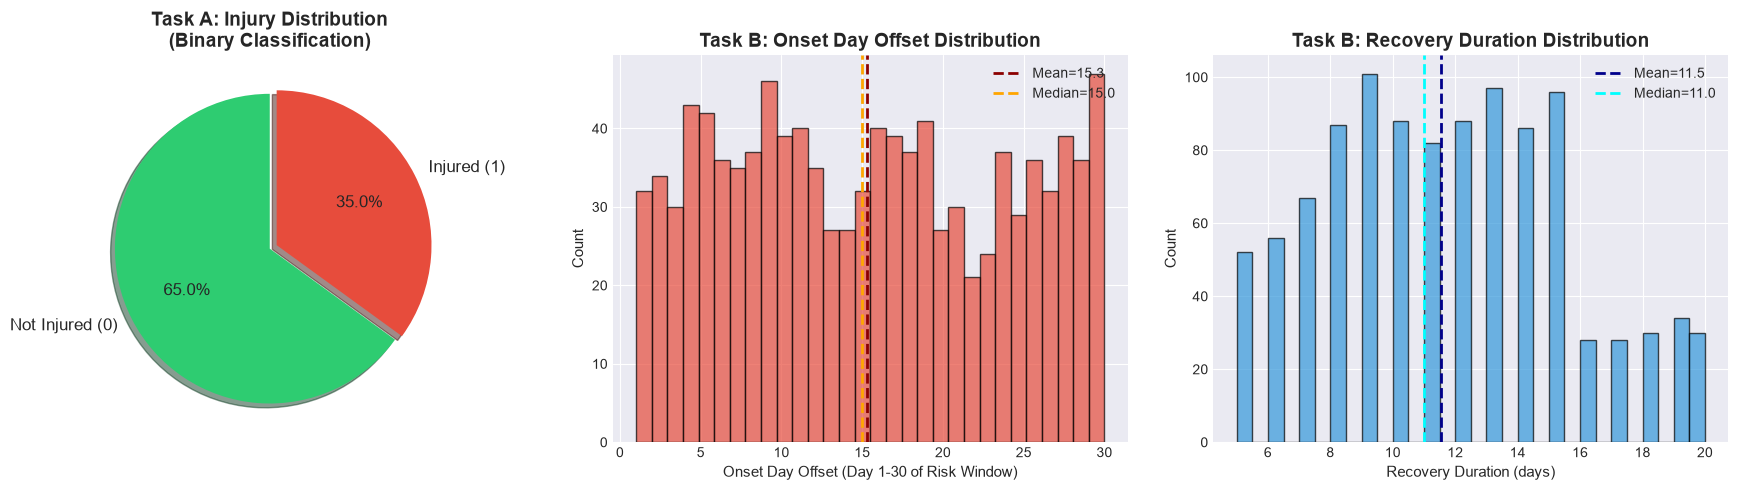


📊 Class Balance: 1950 not injured vs 1050 injured
   Injury Rate: 35.0%

📊 Onset Day Offset: mean=15.3, std=8.8
📊 Recovery Duration: mean=11.5, std=3.9


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Task A: Injury distribution
injury_counts = train_labels['injured_in_risk_window'].value_counts()
colors_pie = ['#2ecc71', '#e74c3c']
axes[0].pie(injury_counts, labels=['Not Injured (0)', 'Injured (1)'],
            autopct='%1.1f%%', colors=colors_pie, startangle=90,
            explode=(0, 0.05), shadow=True, textprops={'fontsize': 12})
axes[0].set_title('Task A: Injury Distribution\n(Binary Classification)', fontsize=14, fontweight='bold')

# Task B: onset_day_offset distribution
injured = train_labels[train_labels['injured_in_risk_window'] == 1]
axes[1].hist(injured['onset_day_offset'], bins=30, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1].axvline(injured['onset_day_offset'].mean(), color='darkred', linestyle='--', linewidth=2,
               label=f"Mean={injured['onset_day_offset'].mean():.1f}")
axes[1].axvline(injured['onset_day_offset'].median(), color='orange', linestyle='--', linewidth=2,
               label=f"Median={injured['onset_day_offset'].median():.1f}")
axes[1].set_xlabel('Onset Day Offset (Day 1-30 of Risk Window)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Task B: Onset Day Offset Distribution', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)

# Task B: recovery_duration distribution
axes[2].hist(injured['recovery_duration'], bins=30, color='#3498db', alpha=0.7, edgecolor='black')
axes[2].axvline(injured['recovery_duration'].mean(), color='darkblue', linestyle='--', linewidth=2,
               label=f"Mean={injured['recovery_duration'].mean():.1f}")
axes[2].axvline(injured['recovery_duration'].median(), color='cyan', linestyle='--', linewidth=2,
               label=f"Median={injured['recovery_duration'].median():.1f}")
axes[2].set_xlabel('Recovery Duration (days)', fontsize=11)
axes[2].set_ylabel('Count', fontsize=11)
axes[2].set_title('Task B: Recovery Duration Distribution', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f'\n📊 Class Balance: {injury_counts[0]} not injured vs {injury_counts[1]} injured')
print(f'   Injury Rate: {injury_counts[1] / len(train_labels) * 100:.1f}%')
print(f'\n📊 Onset Day Offset: mean={injured["onset_day_offset"].mean():.1f}, std={injured["onset_day_offset"].std():.1f}')
print(f'📊 Recovery Duration: mean={injured["recovery_duration"].mean():.1f}, std={injured["recovery_duration"].std():.1f}')

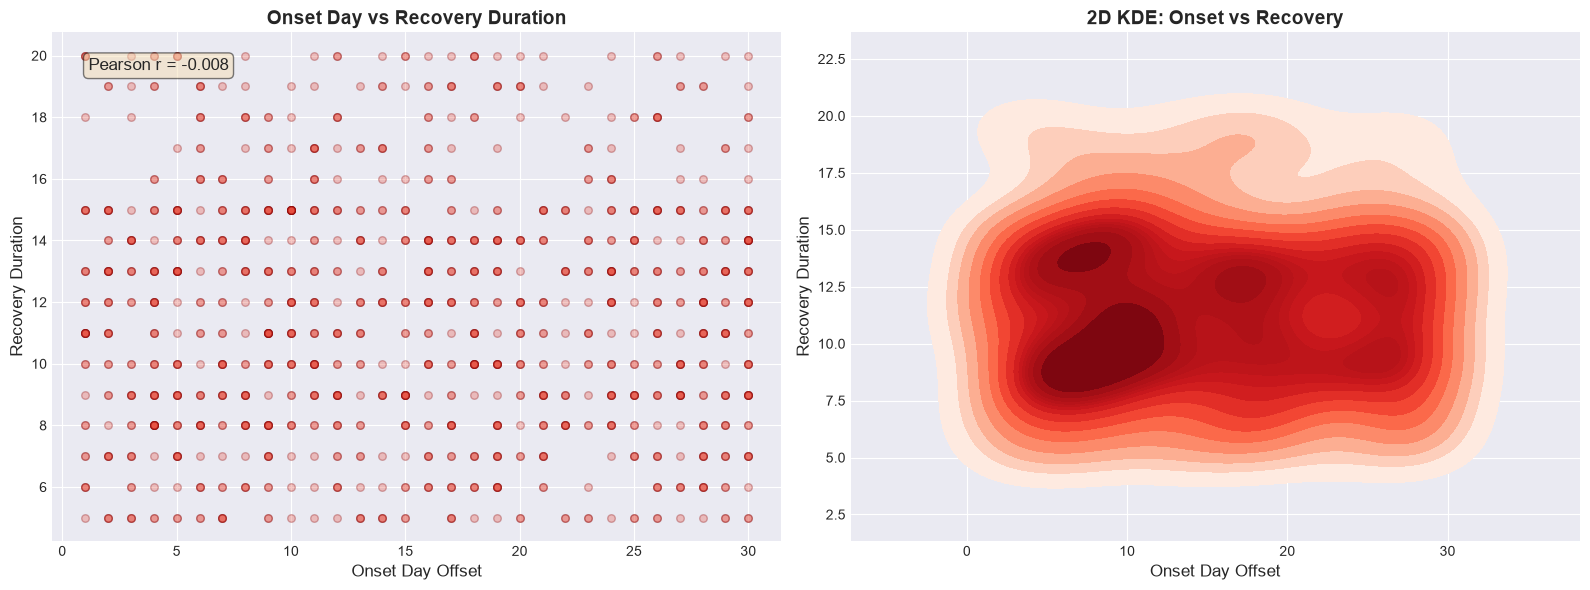

In [5]:
# Onset vs Recovery — Scatter with KDE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Joint scatter
axes[0].scatter(injured['onset_day_offset'], injured['recovery_duration'],
               alpha=0.3, c='#e74c3c', edgecolors='darkred', s=30)
axes[0].set_xlabel('Onset Day Offset', fontsize=12)
axes[0].set_ylabel('Recovery Duration', fontsize=12)
axes[0].set_title('Onset Day vs Recovery Duration', fontsize=14, fontweight='bold')

# Correlation
corr_val = injured['onset_day_offset'].corr(injured['recovery_duration'])
axes[0].text(0.05, 0.95, f'Pearson r = {corr_val:.3f}', transform=axes[0].transAxes,
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2D KDE plot
sns.kdeplot(x=injured['onset_day_offset'], y=injured['recovery_duration'],
           cmap='Reds', fill=True, levels=15, ax=axes[1])
axes[1].set_xlabel('Onset Day Offset', fontsize=12)
axes[1].set_ylabel('Recovery Duration', fontsize=12)
axes[1].set_title('2D KDE: Onset vs Recovery', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 🧬 3. Athlete Metadata Deep Dive
---

In [6]:
# Merge metadata with labels for analysis
meta_labeled = athlete_meta.merge(train_labels, on='athlete_id', how='inner')
meta_labeled['injury_label'] = meta_labeled['injured_in_risk_window'].map({0: 'Not Injured', 1: 'Injured'})

print(f'Merged dataset shape: {meta_labeled.shape}')
display(meta_labeled.head())

Merged dataset shape: (3000, 15)


,athlete_id,sport,age,gender,height_cm,weight_kg_baseline,dominant_side,years_playing,position,team_id,prior_season_injury_count,injured_in_risk_window,onset_day_offset,recovery_duration,injury_label
0,1,Football,24,male,183.0,74.0,right,5,Goalkeeper,FOO-3,1,0,NaN,NaN,Not Injured
1,2,Athletics,20,female,165.3,56.0,right,6,Throws,ATH-2,1,1,23.0,10.0,Injured
2,3,Tennis,18,male,186.1,50.4,right,5,Singles,TEN-5,1,0,NaN,NaN,Not Injured
3,4,Football,22,female,163.3,49.3,right,4,Forward,FOO-2,0,1,22.0,15.0,Injured
4,5,Tennis,22,male,157.3,55.2,right,11,Singles,TEN-3,0,0,NaN,NaN,Not Injured


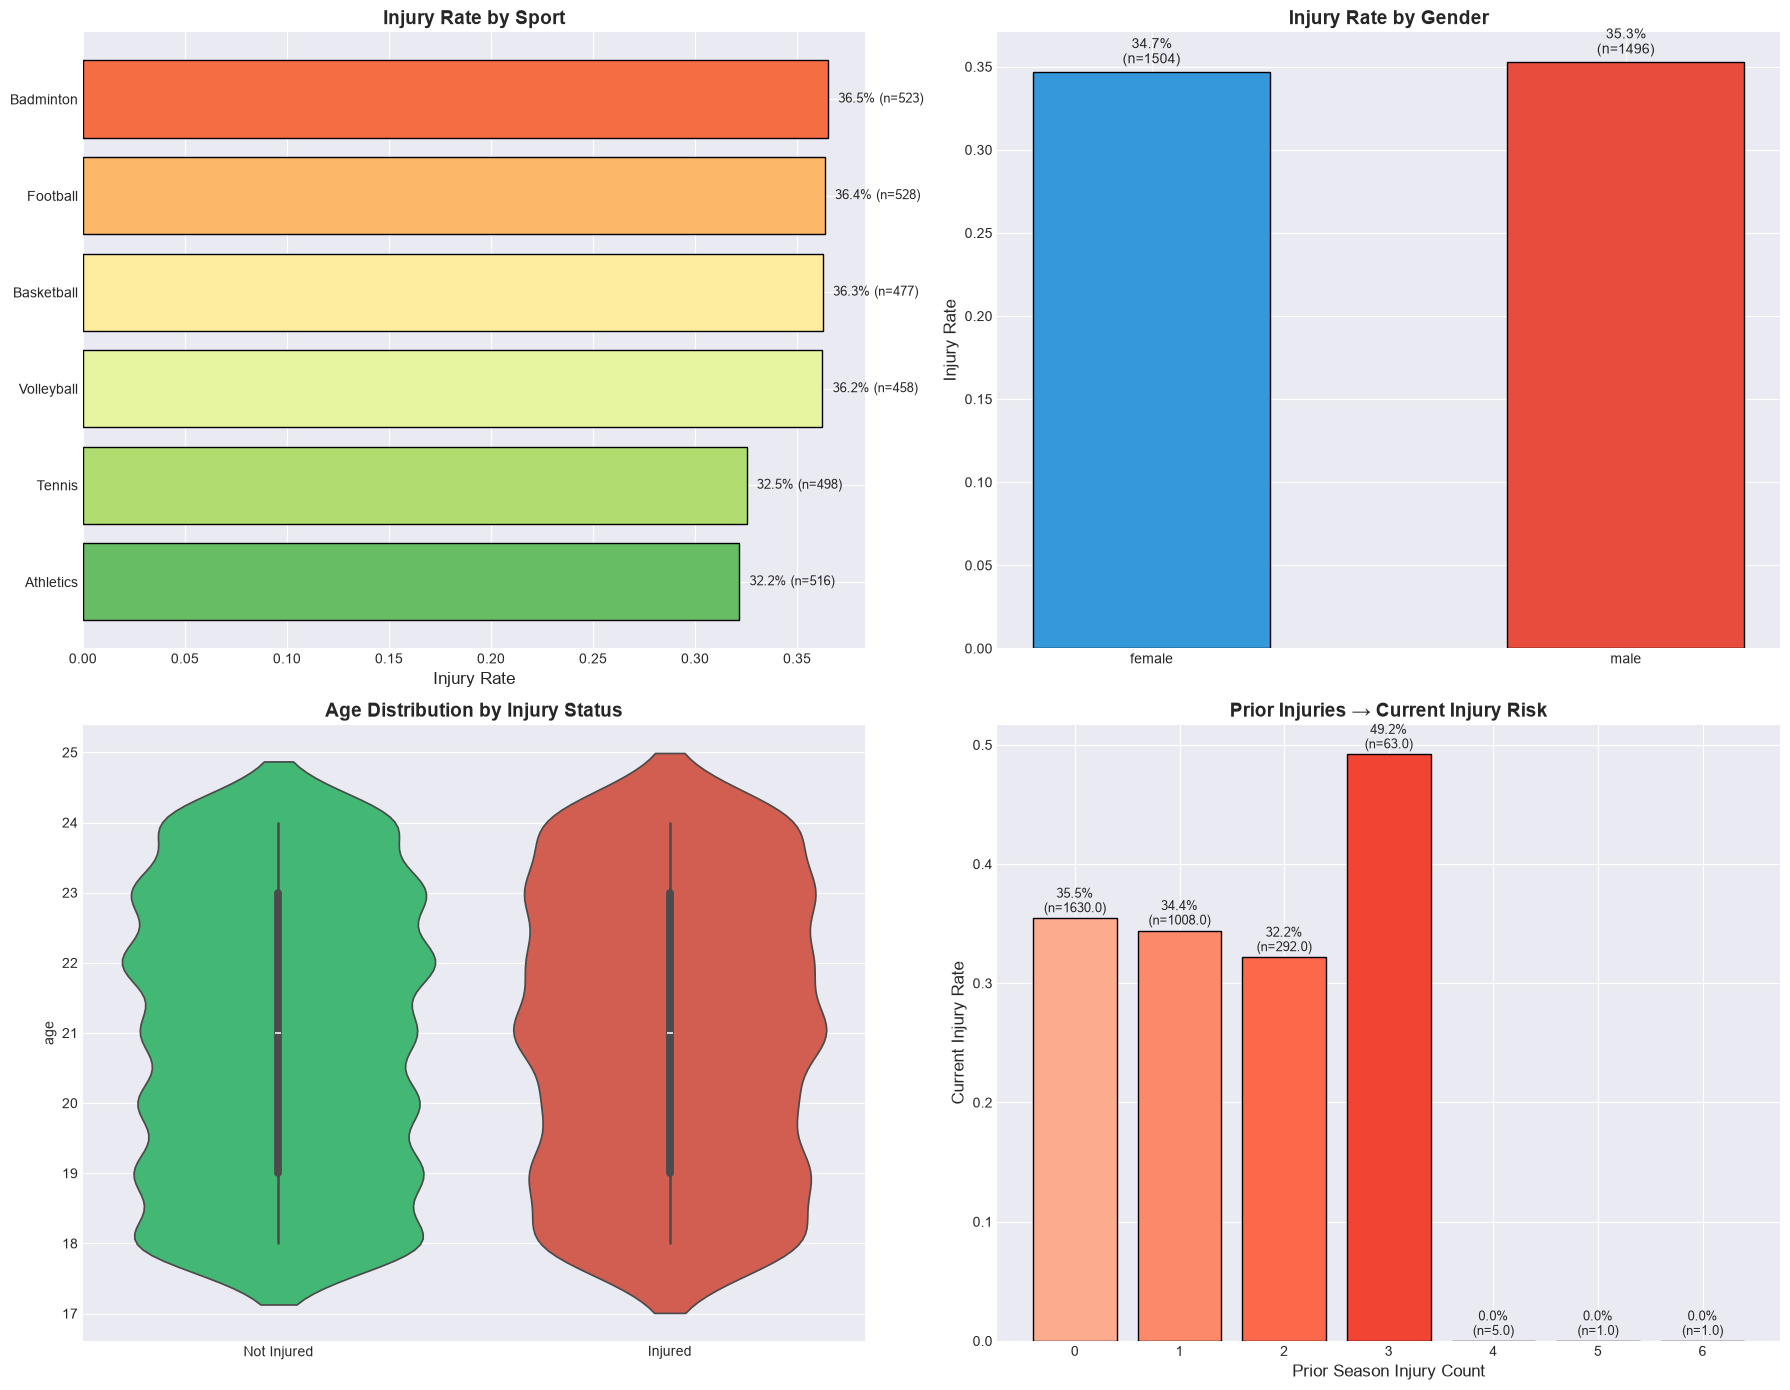

In [7]:
# Sport-wise injury rate
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Injury rate by sport
sport_injury = meta_labeled.groupby('sport')['injured_in_risk_window'].agg(['mean', 'count']).reset_index()
sport_injury.columns = ['sport', 'injury_rate', 'count']
sport_injury = sport_injury.sort_values('injury_rate', ascending=True)

colors_bar = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(sport_injury)))
axes[0, 0].barh(sport_injury['sport'], sport_injury['injury_rate'], color=colors_bar, edgecolor='black')
axes[0, 0].set_xlabel('Injury Rate', fontsize=12)
axes[0, 0].set_title('Injury Rate by Sport', fontsize=14, fontweight='bold')
for i, (rate, count) in enumerate(zip(sport_injury['injury_rate'], sport_injury['count'])):
    axes[0, 0].text(rate + 0.005, i, f'{rate:.1%} (n={count})', va='center', fontsize=9)

# Injury rate by gender
gender_injury = meta_labeled.groupby('gender')['injured_in_risk_window'].agg(['mean', 'count']).reset_index()
gender_injury.columns = ['gender', 'injury_rate', 'count']
bars = axes[0, 1].bar(gender_injury['gender'], gender_injury['injury_rate'],
                       color=['#3498db', '#e74c3c'], edgecolor='black', width=0.5)
axes[0, 1].set_ylabel('Injury Rate', fontsize=12)
axes[0, 1].set_title('Injury Rate by Gender', fontsize=14, fontweight='bold')
for bar, rate, count in zip(bars, gender_injury['injury_rate'], gender_injury['count']):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{rate:.1%}\n(n={count})', ha='center', fontsize=10)

# Age distribution by injury status
sns.violinplot(x='injury_label', y='age', data=meta_labeled, ax=axes[1, 0],
              palette=['#2ecc71', '#e74c3c'], inner='box')
axes[1, 0].set_title('Age Distribution by Injury Status', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('')

# Prior injury count vs current injury
prior_injury = meta_labeled.groupby('prior_season_injury_count')['injured_in_risk_window'].agg(['mean', 'count']).reset_index()
prior_injury.columns = ['prior_injuries', 'injury_rate', 'count']
axes[1, 1].bar(prior_injury['prior_injuries'], prior_injury['injury_rate'],
              color=plt.cm.Reds(np.linspace(0.3, 0.9, len(prior_injury))), edgecolor='black')
axes[1, 1].set_xlabel('Prior Season Injury Count', fontsize=12)
axes[1, 1].set_ylabel('Current Injury Rate', fontsize=12)
axes[1, 1].set_title('Prior Injuries → Current Injury Risk', fontsize=14, fontweight='bold')
for i, row in prior_injury.iterrows():
    axes[1, 1].text(row['prior_injuries'], row['injury_rate'] + 0.005,
                    f'{row["injury_rate"]:.1%}\n(n={row["count"]})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

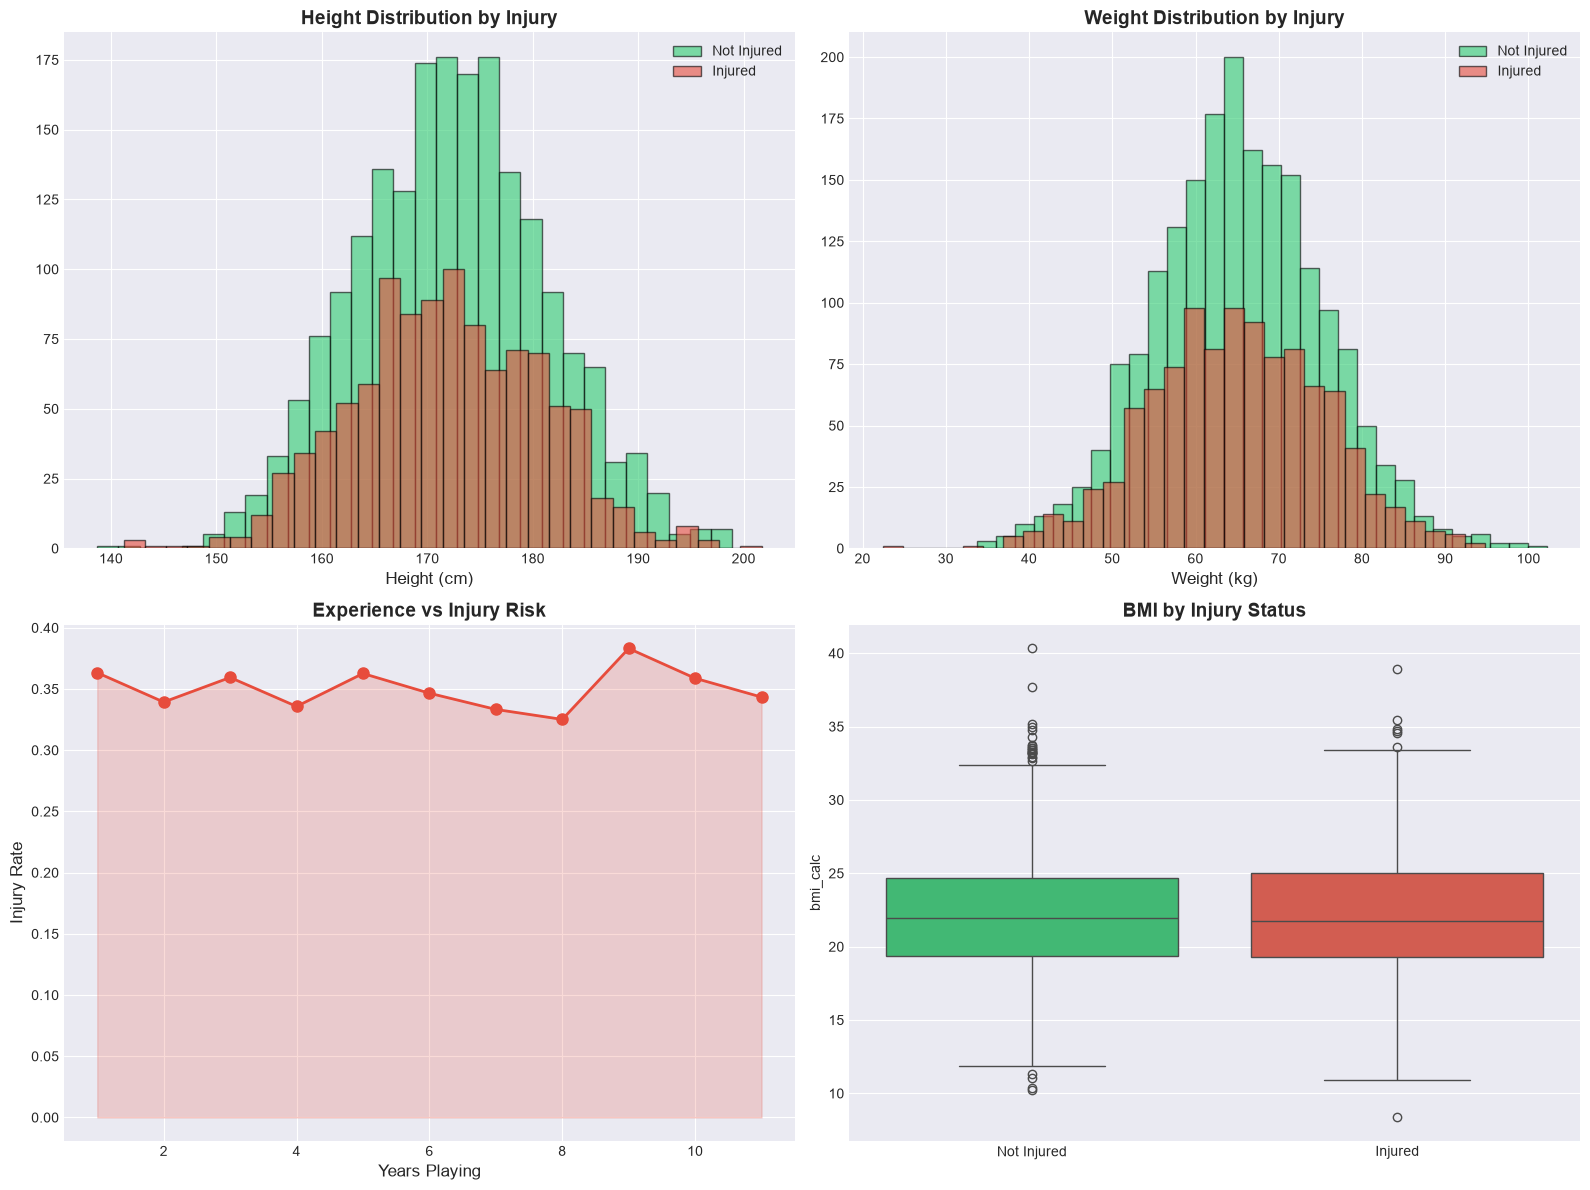

In [8]:
# Height, Weight, BMI, Years Playing analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Height distribution by injury
for label, color in [('Not Injured', '#2ecc71'), ('Injured', '#e74c3c')]:
    subset = meta_labeled[meta_labeled['injury_label'] == label]
    axes[0, 0].hist(subset['height_cm'], bins=30, alpha=0.6, color=color, label=label, edgecolor='black')
axes[0, 0].set_xlabel('Height (cm)', fontsize=12)
axes[0, 0].set_title('Height Distribution by Injury', fontsize=14, fontweight='bold')
axes[0, 0].legend()

# Weight distribution by injury
for label, color in [('Not Injured', '#2ecc71'), ('Injured', '#e74c3c')]:
    subset = meta_labeled[meta_labeled['injury_label'] == label]
    axes[0, 1].hist(subset['weight_kg_baseline'], bins=30, alpha=0.6, color=color, label=label, edgecolor='black')
axes[0, 1].set_xlabel('Weight (kg)', fontsize=12)
axes[0, 1].set_title('Weight Distribution by Injury', fontsize=14, fontweight='bold')
axes[0, 1].legend()

# Years playing vs injury rate
yp_injury = meta_labeled.groupby('years_playing')['injured_in_risk_window'].mean().reset_index()
axes[1, 0].plot(yp_injury['years_playing'], yp_injury['injured_in_risk_window'],
               'o-', color='#e74c3c', markersize=8, linewidth=2)
axes[1, 0].fill_between(yp_injury['years_playing'], yp_injury['injured_in_risk_window'], alpha=0.2, color='#e74c3c')
axes[1, 0].set_xlabel('Years Playing', fontsize=12)
axes[1, 0].set_ylabel('Injury Rate', fontsize=12)
axes[1, 0].set_title('Experience vs Injury Risk', fontsize=14, fontweight='bold')

# BMI (calculated) vs injury
meta_labeled['bmi_calc'] = meta_labeled['weight_kg_baseline'] / (meta_labeled['height_cm']/100)**2
sns.boxplot(x='injury_label', y='bmi_calc', data=meta_labeled, ax=axes[1, 1],
           palette=['#2ecc71', '#e74c3c'])
axes[1, 1].set_title('BMI by Injury Status', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('')

plt.tight_layout()
plt.show()

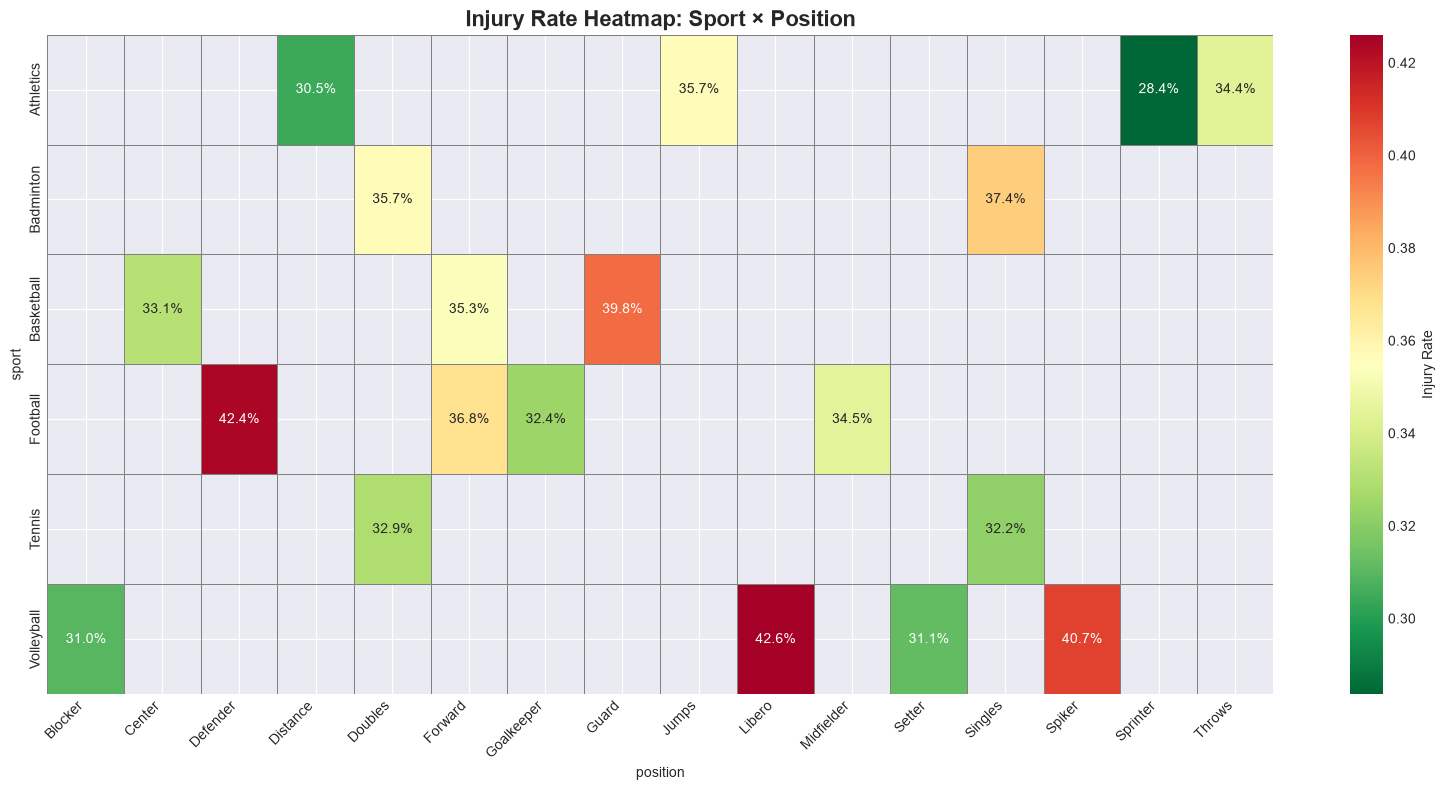

In [9]:
# Position analysis — injury rate heatmap by sport + position
pos_sport_injury = meta_labeled.groupby(['sport', 'position'])['injured_in_risk_window'].agg(['mean', 'count']).reset_index()
pos_sport_injury.columns = ['sport', 'position', 'injury_rate', 'count']
pos_sport_injury = pos_sport_injury[pos_sport_injury['count'] >= 5]  # filter small groups

pivot = pos_sport_injury.pivot(index='sport', columns='position', values='injury_rate')

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn_r', ax=ax,
           linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Injury Rate'})
ax.set_title('Injury Rate Heatmap: Sport × Position', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

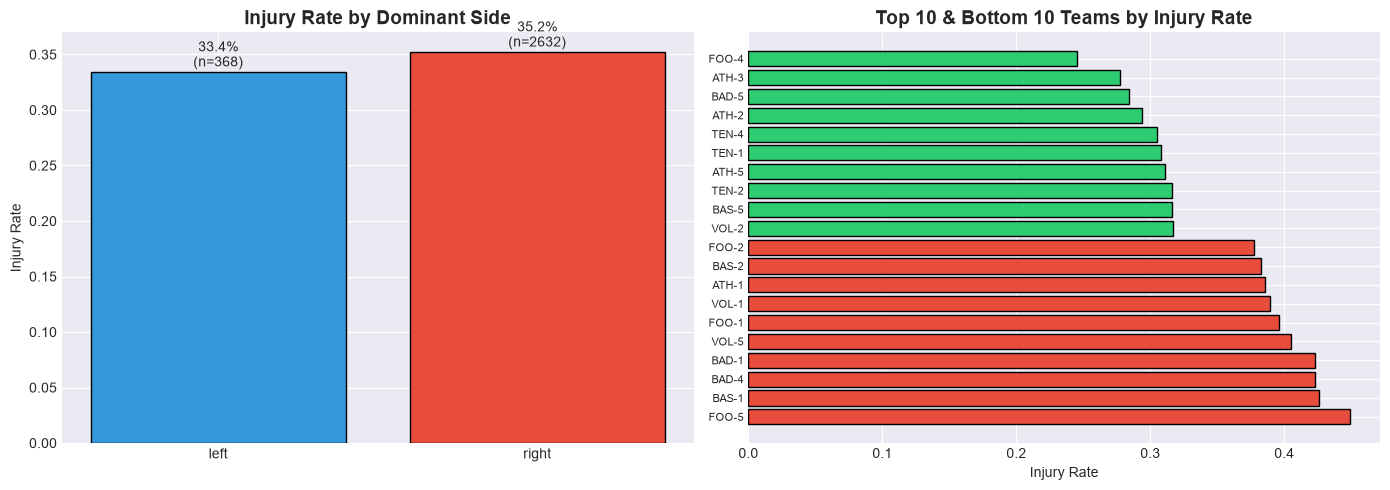

In [10]:
# Dominant side analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

side_injury = meta_labeled.groupby('dominant_side')['injured_in_risk_window'].agg(['mean', 'count']).reset_index()
side_injury.columns = ['side', 'injury_rate', 'count']
axes[0].bar(side_injury['side'], side_injury['injury_rate'],
           color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_ylabel('Injury Rate')
axes[0].set_title('Injury Rate by Dominant Side', fontsize=14, fontweight='bold')
for i, row in side_injury.iterrows():
    axes[0].text(i, row['injury_rate'] + 0.005, f'{row["injury_rate"]:.1%}\n(n={row["count"]})', ha='center')

# Team-level analysis — top/bottom teams by injury rate
team_injury = meta_labeled.groupby('team_id')['injured_in_risk_window'].agg(['mean', 'count']).reset_index()
team_injury.columns = ['team_id', 'injury_rate', 'count']
team_injury = team_injury[team_injury['count'] >= 10].sort_values('injury_rate', ascending=False)

top_bottom = pd.concat([team_injury.head(10), team_injury.tail(10)])
colors_tb = ['#e74c3c'] * 10 + ['#2ecc71'] * 10
axes[1].barh(range(len(top_bottom)), top_bottom['injury_rate'], color=colors_tb, edgecolor='black')
axes[1].set_yticks(range(len(top_bottom)))
axes[1].set_yticklabels(top_bottom['team_id'], fontsize=8)
axes[1].set_xlabel('Injury Rate')
axes[1].set_title('Top 10 & Bottom 10 Teams by Injury Rate', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 🏃 4. Daily Activity Analysis
---

In [11]:
# Parse dates
daily_activity['ActivityDate'] = pd.to_datetime(daily_activity['ActivityDate'])

# Merge with labels
daily_labeled = daily_activity.merge(train_labels[['athlete_id', 'injured_in_risk_window']],
                                     left_on='Id', right_on='athlete_id', how='inner')
daily_labeled['injury_label'] = daily_labeled['injured_in_risk_window'].map({0: 'Not Injured', 1: 'Injured'})

print(f'Daily activity merged shape: {daily_labeled.shape}')
print(f'Date range: {daily_labeled["ActivityDate"].min()} to {daily_labeled["ActivityDate"].max()}')
print(f'Unique athletes: {daily_labeled["Id"].nunique()}')

Daily activity merged shape: (180000, 13)
Date range: 2026-01-05 00:00:00 to 2026-03-05 00:00:00
Unique athletes: 3000


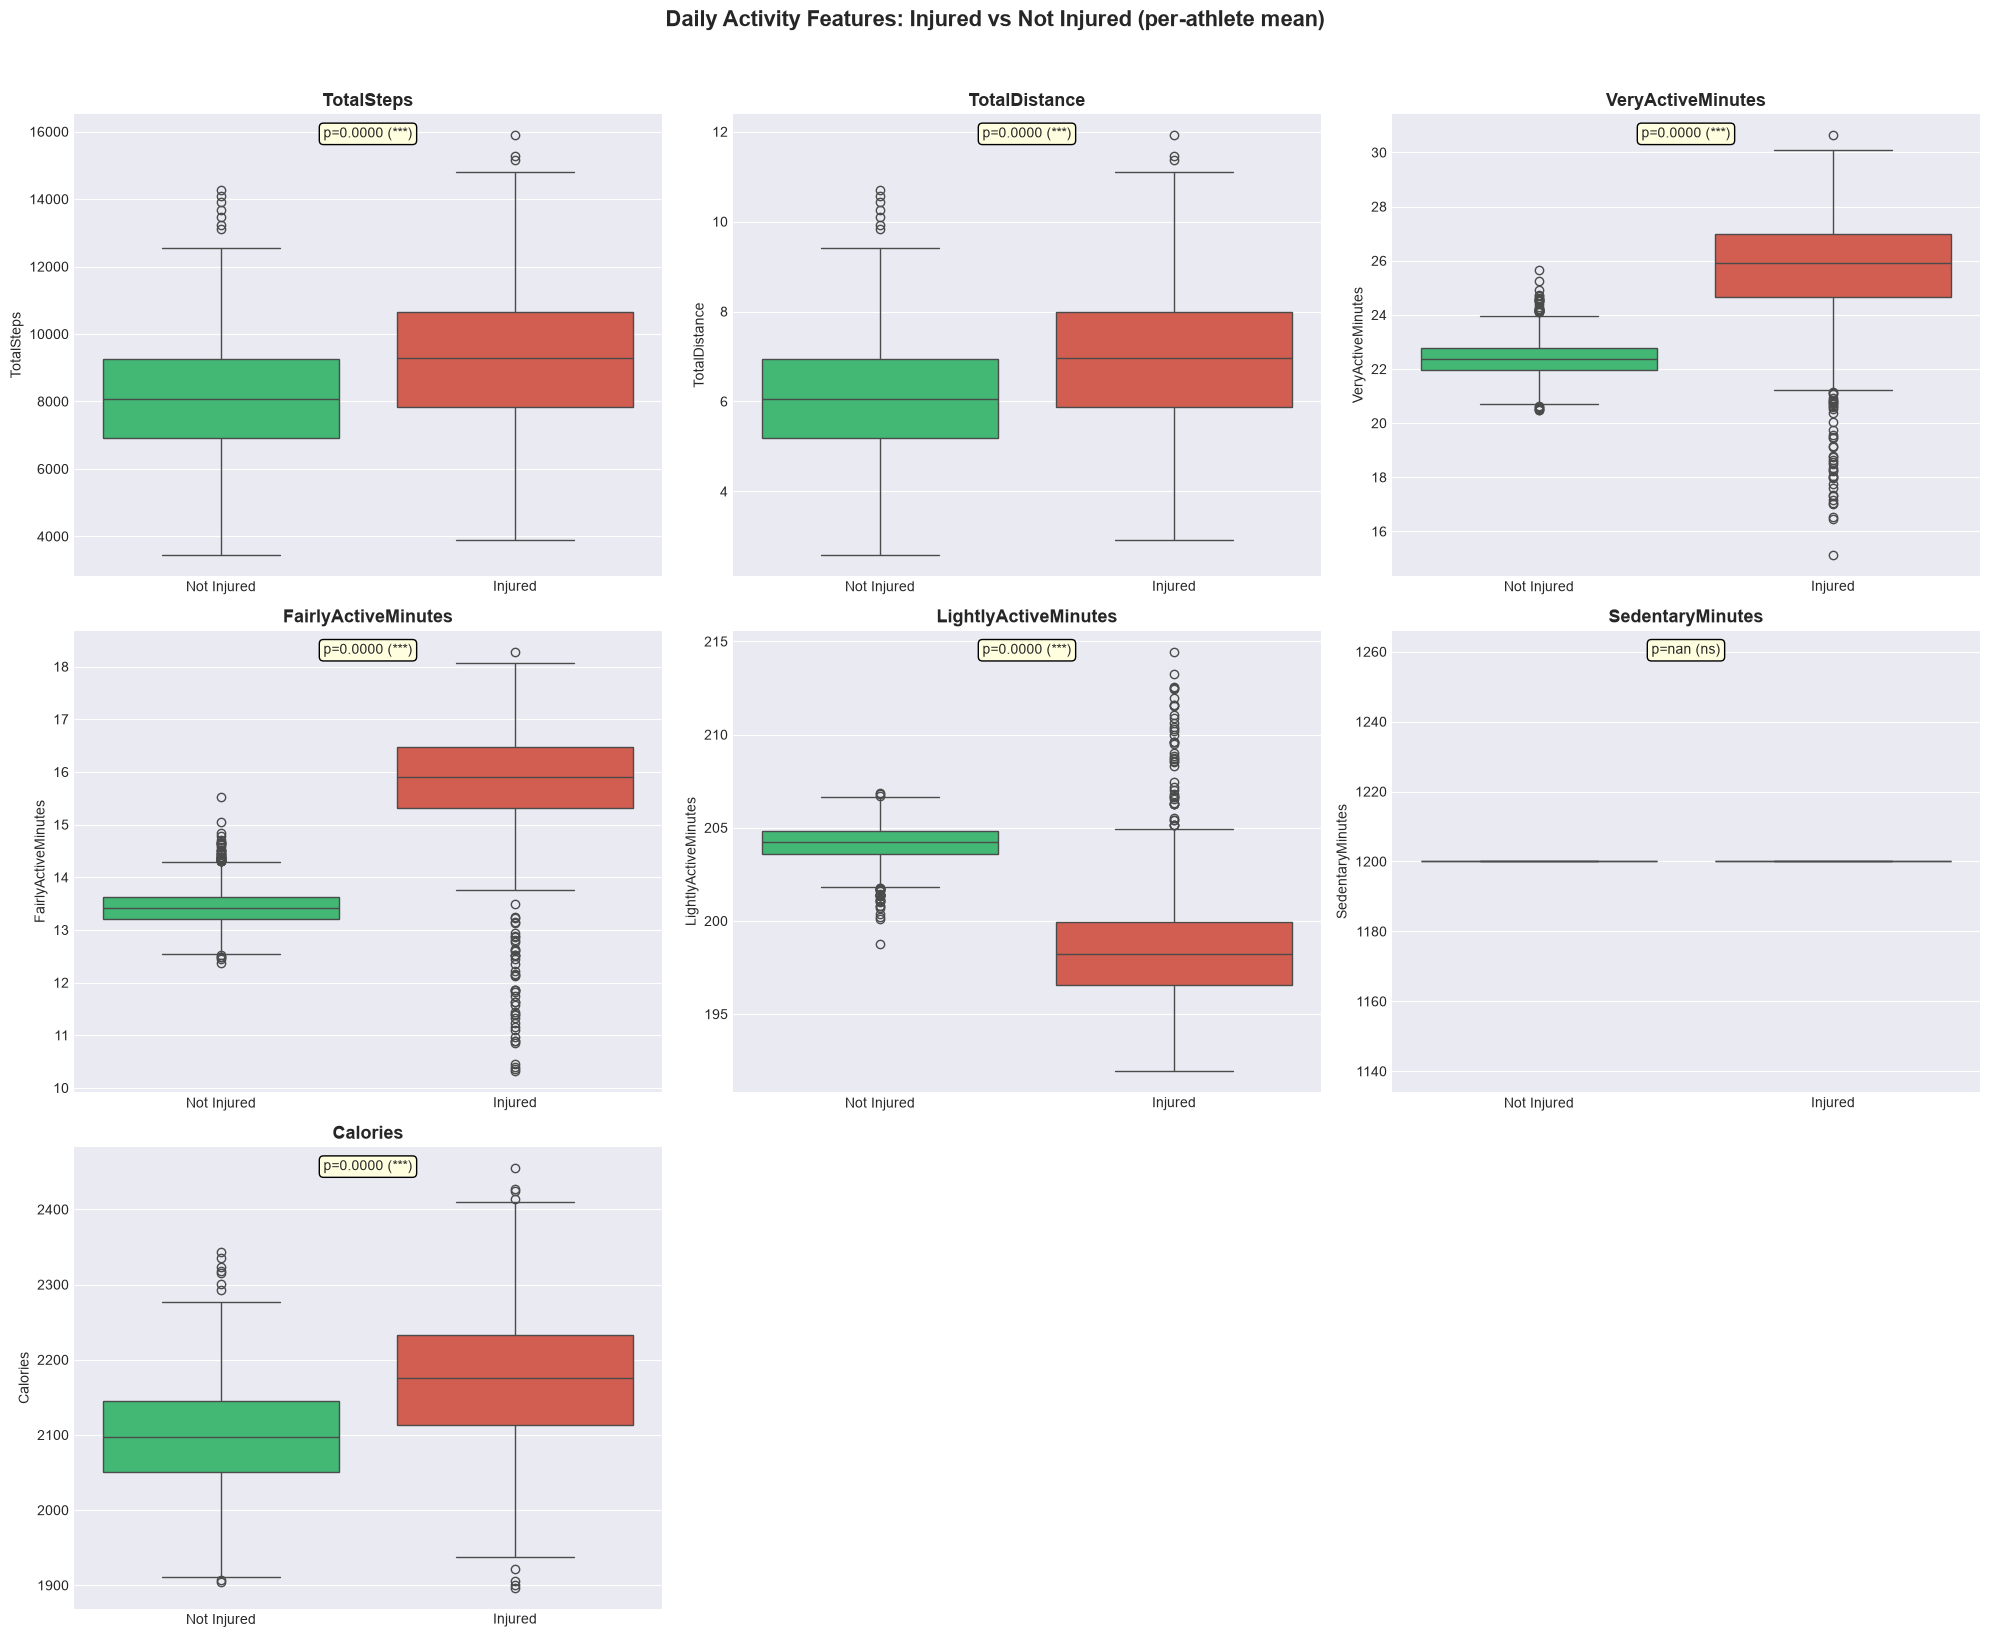

In [12]:
# Daily activity distributions: Injured vs Not Injured
activity_cols = ['TotalSteps', 'TotalDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
                 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories']

fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(activity_cols):
    # Aggregate per athlete
    agg = daily_labeled.groupby(['Id', 'injury_label'])[col].mean().reset_index()
    sns.boxplot(x='injury_label', y=col, data=agg, ax=axes[i],
               palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('')
    
    # Add statistical test
    group0 = agg[agg['injury_label'] == 'Not Injured'][col]
    group1 = agg[agg['injury_label'] == 'Injured'][col]
    stat, pval = stats.mannwhitneyu(group0.dropna(), group1.dropna(), alternative='two-sided')
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    axes[i].text(0.5, 0.95, f'p={pval:.4f} ({sig})', transform=axes[i].transAxes,
                ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow'))

# Hide extra subplots
for j in range(len(activity_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Daily Activity Features: Injured vs Not Injured (per-athlete mean)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

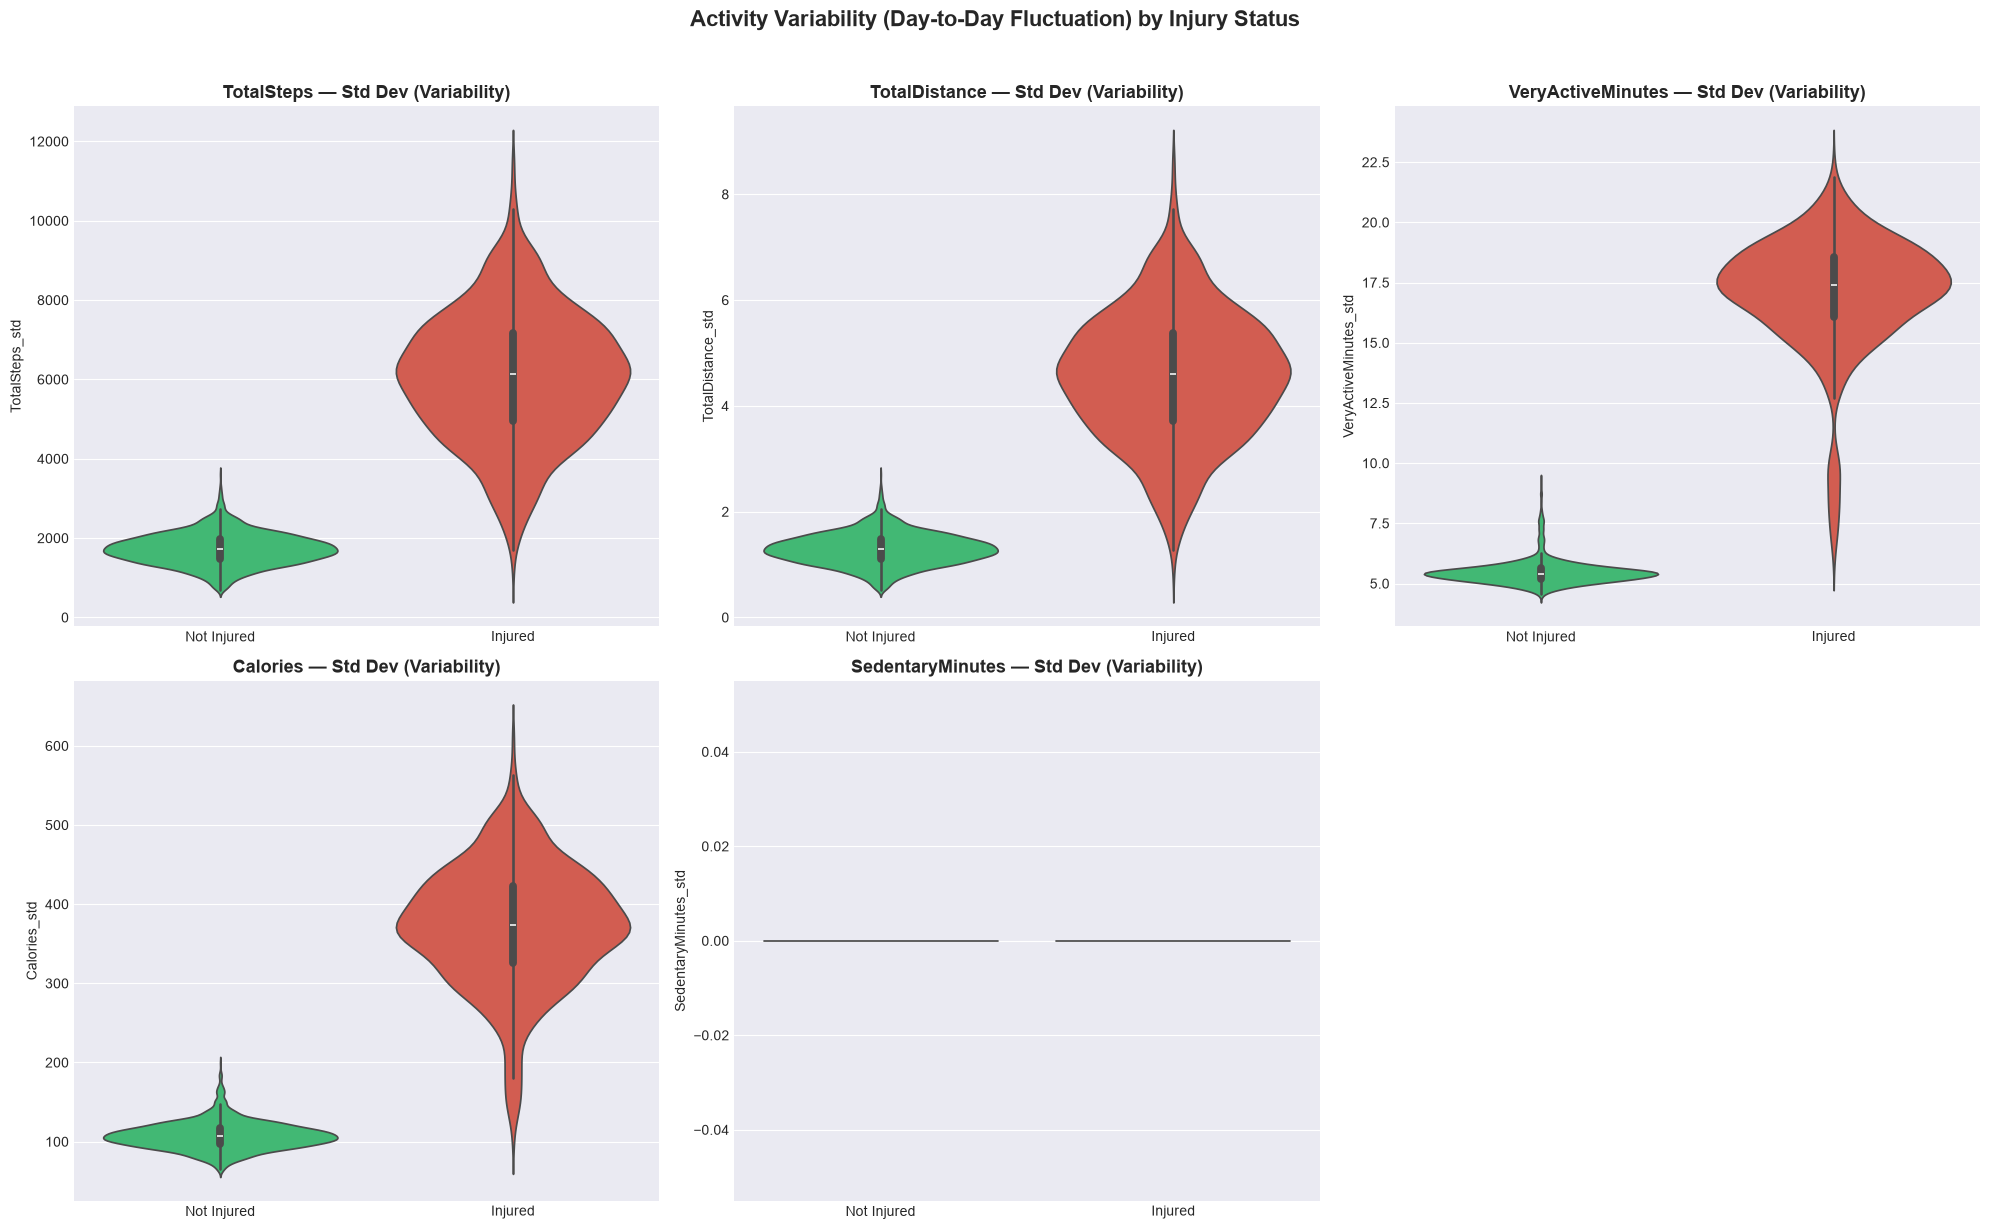

In [13]:
# Activity variability — standard deviation as a feature signal
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

variability_cols = ['TotalSteps', 'TotalDistance', 'VeryActiveMinutes', 'Calories', 'SedentaryMinutes']

for i, col in enumerate(variability_cols):
    agg_std = daily_labeled.groupby(['Id', 'injury_label'])[col].std().reset_index()
    agg_std.columns = ['Id', 'injury_label', f'{col}_std']
    sns.violinplot(x='injury_label', y=f'{col}_std', data=agg_std, ax=axes[i],
                  palette=['#2ecc71', '#e74c3c'], inner='box')
    axes[i].set_title(f'{col} — Std Dev (Variability)', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('')

axes[-1].set_visible(False)
plt.suptitle('Activity Variability (Day-to-Day Fluctuation) by Injury Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

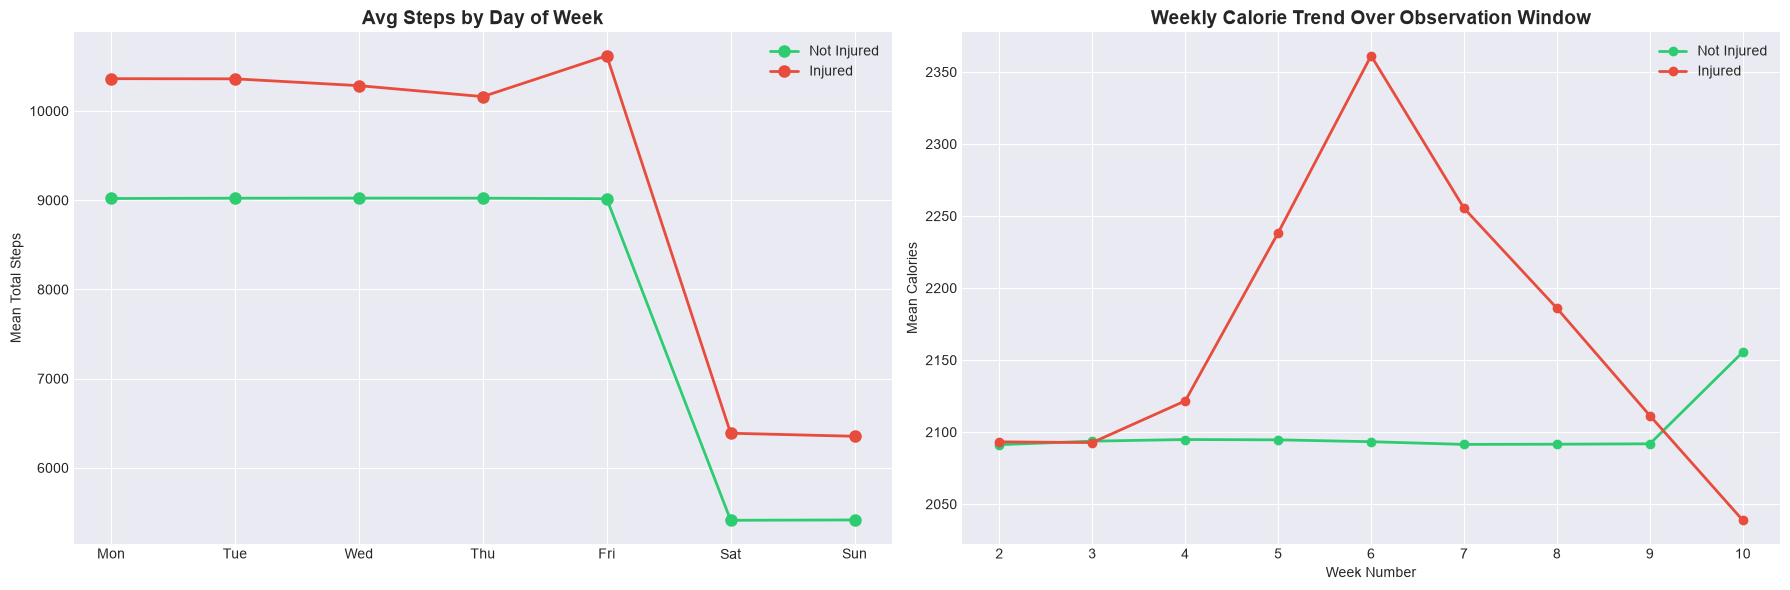

In [14]:
# Temporal trends — weekly activity patterns
daily_labeled['day_of_week'] = daily_labeled['ActivityDate'].dt.dayofweek
daily_labeled['week_num'] = daily_labeled['ActivityDate'].dt.isocalendar().week.astype(int)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Day of week patterns
dow_data = daily_labeled.groupby(['day_of_week', 'injury_label'])['TotalSteps'].mean().reset_index()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
for label, color in [('Not Injured', '#2ecc71'), ('Injured', '#e74c3c')]:
    subset = dow_data[dow_data['injury_label'] == label]
    axes[0].plot(subset['day_of_week'], subset['TotalSteps'], 'o-', color=color,
                label=label, linewidth=2, markersize=8)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_names)
axes[0].set_title('Avg Steps by Day of Week', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Mean Total Steps')
axes[0].legend()

# Weekly trend over time
weekly = daily_labeled.groupby(['week_num', 'injury_label'])['Calories'].mean().reset_index()
for label, color in [('Not Injured', '#2ecc71'), ('Injured', '#e74c3c')]:
    subset = weekly[weekly['injury_label'] == label]
    axes[1].plot(subset['week_num'], subset['Calories'], 'o-', color=color,
                label=label, linewidth=2, markersize=6)
axes[1].set_title('Weekly Calorie Trend Over Observation Window', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Week Number')
axes[1].set_ylabel('Mean Calories')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 💓 5. Hourly Biometrics Analysis
---

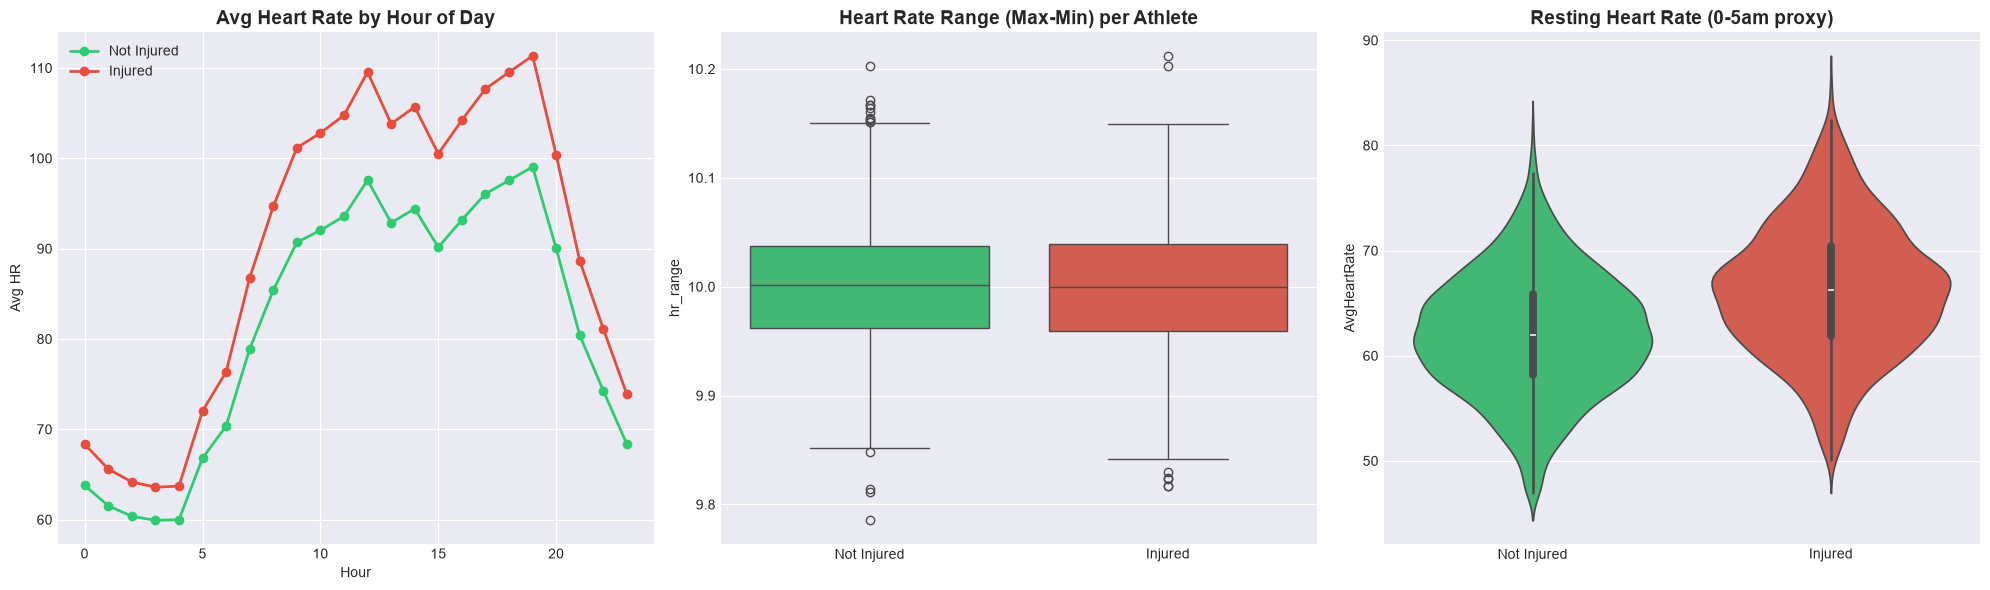

In [15]:
# Parse hourly timestamps
hourly_heartrate['ActivityHour'] = pd.to_datetime(hourly_heartrate['ActivityHour'])
hourly_heartrate['hour'] = hourly_heartrate['ActivityHour'].dt.hour

# Merge with labels
hr_labeled = hourly_heartrate.merge(train_labels[['athlete_id', 'injured_in_risk_window']],
                                     left_on='Id', right_on='athlete_id', how='inner')
hr_labeled['injury_label'] = hr_labeled['injured_in_risk_window'].map({0: 'Not Injured', 1: 'Injured'})

# Hourly heart rate pattern
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Average HR by hour
hr_hourly = hr_labeled.groupby(['hour', 'injury_label'])['AvgHeartRate'].mean().reset_index()
for label, color in [('Not Injured', '#2ecc71'), ('Injured', '#e74c3c')]:
    subset = hr_hourly[hr_hourly['injury_label'] == label]
    axes[0].plot(subset['hour'], subset['AvgHeartRate'], 'o-', color=color,
                label=label, linewidth=2, markersize=6)
axes[0].set_title('Avg Heart Rate by Hour of Day', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg HR')
axes[0].legend()

# Heart Rate Range (Max - Min) per hour
hr_labeled['hr_range'] = hr_labeled['MaxHeartRate'] - hr_labeled['MinHeartRate']
hr_range_agg = hr_labeled.groupby(['Id', 'injury_label'])['hr_range'].mean().reset_index()
sns.boxplot(x='injury_label', y='hr_range', data=hr_range_agg, ax=axes[1],
           palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Heart Rate Range (Max-Min) per Athlete', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')

# Resting HR proxy (nighttime avg: 0-5am)
resting = hr_labeled[hr_labeled['hour'].between(0, 5)]
resting_agg = resting.groupby(['Id', 'injury_label'])['AvgHeartRate'].mean().reset_index()
sns.violinplot(x='injury_label', y='AvgHeartRate', data=resting_agg, ax=axes[2],
              palette=['#2ecc71', '#e74c3c'], inner='box')
axes[2].set_title('Resting Heart Rate (0-5am proxy)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

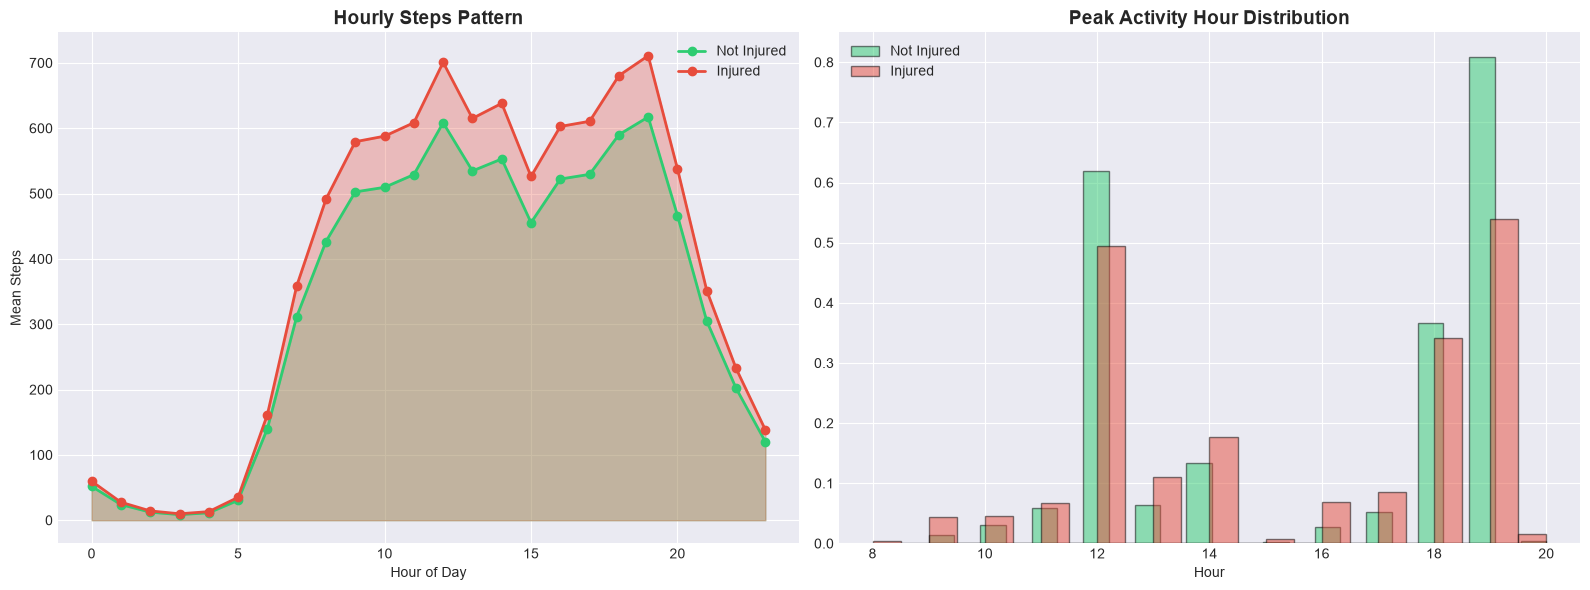

In [16]:
# Hourly Steps pattern
hourly_steps['ActivityHour'] = pd.to_datetime(hourly_steps['ActivityHour'])
hourly_steps['hour'] = hourly_steps['ActivityHour'].dt.hour

steps_labeled = hourly_steps.merge(train_labels[['athlete_id', 'injured_in_risk_window']],
                                    left_on='Id', right_on='athlete_id', how='inner')
steps_labeled['injury_label'] = steps_labeled['injured_in_risk_window'].map({0: 'Not Injured', 1: 'Injured'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Steps by hour
steps_hourly = steps_labeled.groupby(['hour', 'injury_label'])['StepTotal'].mean().reset_index()
for label, color in [('Not Injured', '#2ecc71'), ('Injured', '#e74c3c')]:
    subset = steps_hourly[steps_hourly['injury_label'] == label]
    axes[0].fill_between(subset['hour'], subset['StepTotal'], alpha=0.3, color=color)
    axes[0].plot(subset['hour'], subset['StepTotal'], 'o-', color=color,
                label=label, linewidth=2)
axes[0].set_title('Hourly Steps Pattern', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Mean Steps')
axes[0].legend()

# Peak activity hour distribution
peak_hour = steps_labeled.groupby(['Id', 'injury_label'])['StepTotal'].apply(
    lambda x: steps_labeled.loc[x.index, 'hour'].iloc[x.values.argmax()] if len(x) > 0 else np.nan
).reset_index()
peak_hour.columns = ['Id', 'injury_label', 'peak_hour']

for label, color in [('Not Injured', '#2ecc71'), ('Injured', '#e74c3c')]:
    subset = peak_hour[peak_hour['injury_label'] == label]
    axes[1].hist(subset['peak_hour'].dropna(), bins=24, alpha=0.5, color=color,
                label=label, edgecolor='black', density=True)
axes[1].set_title('Peak Activity Hour Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].legend()

plt.tight_layout()
plt.show()

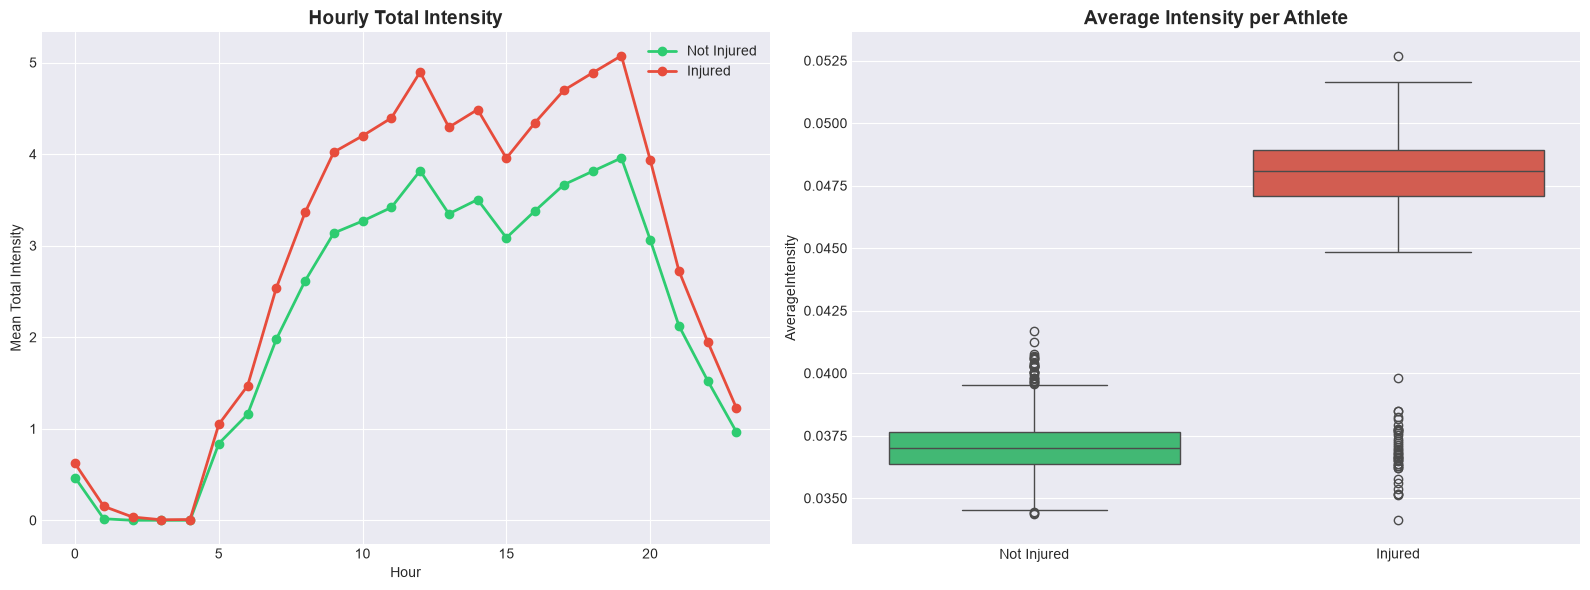

In [17]:
# Hourly Intensity analysis
hourly_intensity['ActivityHour'] = pd.to_datetime(hourly_intensity['ActivityHour'])
hourly_intensity['hour'] = hourly_intensity['ActivityHour'].dt.hour

intensity_labeled = hourly_intensity.merge(train_labels[['athlete_id', 'injured_in_risk_window']],
                                           left_on='Id', right_on='athlete_id', how='inner')
intensity_labeled['injury_label'] = intensity_labeled['injured_in_risk_window'].map({0: 'Not Injured', 1: 'Injured'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total intensity by hour
int_hourly = intensity_labeled.groupby(['hour', 'injury_label'])['TotalIntensity'].mean().reset_index()
for label, color in [('Not Injured', '#2ecc71'), ('Injured', '#e74c3c')]:
    subset = int_hourly[int_hourly['injury_label'] == label]
    axes[0].plot(subset['hour'], subset['TotalIntensity'], 'o-', color=color,
                label=label, linewidth=2)
axes[0].set_title('Hourly Total Intensity', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Mean Total Intensity')
axes[0].legend()

# Average intensity per athlete
avg_int = intensity_labeled.groupby(['Id', 'injury_label'])['AverageIntensity'].mean().reset_index()
sns.boxplot(x='injury_label', y='AverageIntensity', data=avg_int, ax=axes[1],
           palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Average Intensity per Athlete', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

---
## 😴 6. Sleep Analysis
---

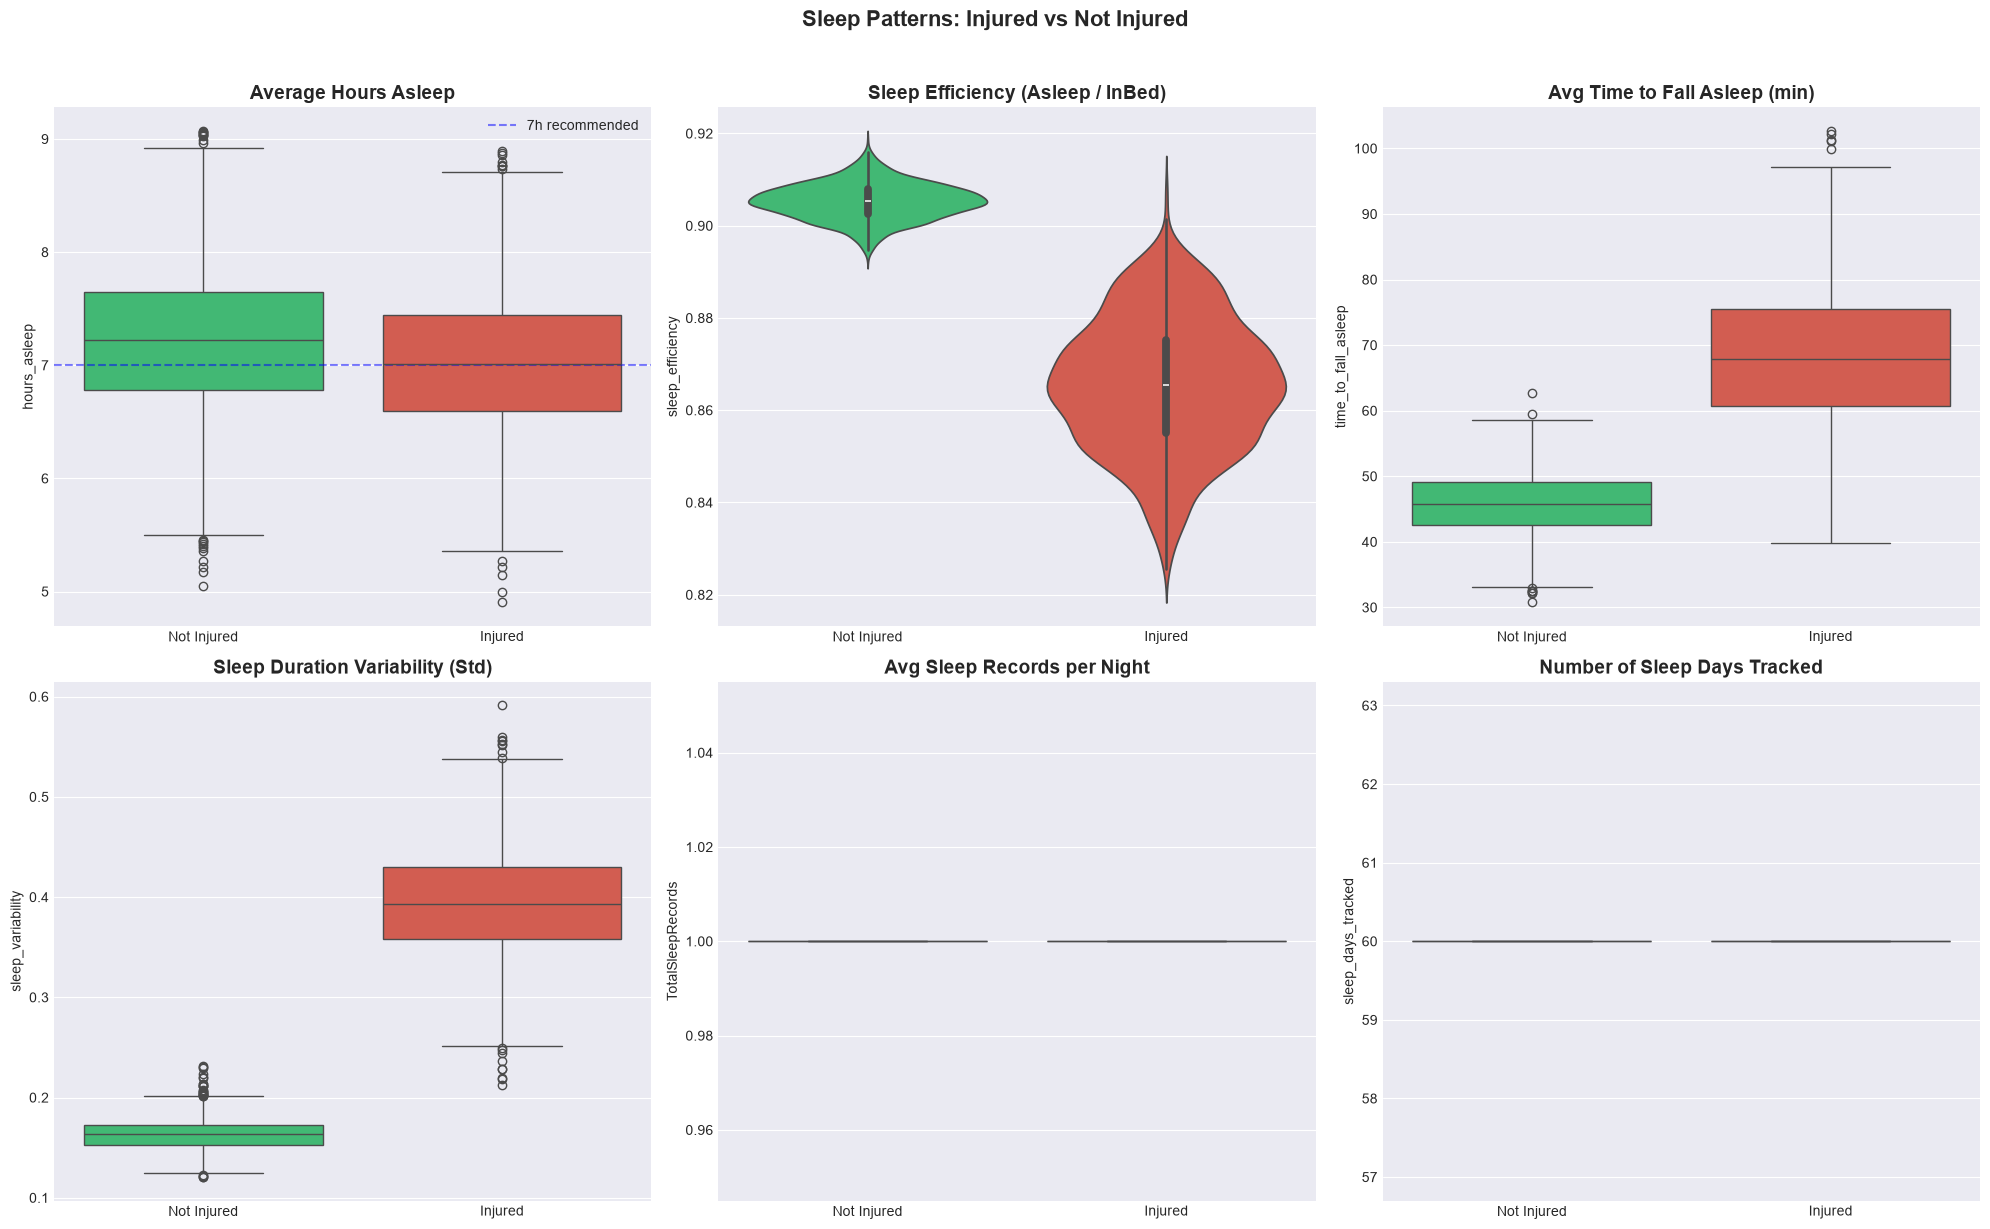

In [18]:
sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'])

sleep_labeled = sleep.merge(train_labels[['athlete_id', 'injured_in_risk_window']],
                             left_on='Id', right_on='athlete_id', how='inner')
sleep_labeled['injury_label'] = sleep_labeled['injured_in_risk_window'].map({0: 'Not Injured', 1: 'Injured'})

# Derived features
sleep_labeled['sleep_efficiency'] = sleep_labeled['TotalMinutesAsleep'] / sleep_labeled['TotalTimeInBed']
sleep_labeled['time_to_fall_asleep'] = sleep_labeled['TotalTimeInBed'] - sleep_labeled['TotalMinutesAsleep']
sleep_labeled['hours_asleep'] = sleep_labeled['TotalMinutesAsleep'] / 60

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Sleep duration
sleep_agg = sleep_labeled.groupby(['Id', 'injury_label']).agg({
    'hours_asleep': 'mean',
    'sleep_efficiency': 'mean',
    'time_to_fall_asleep': 'mean',
    'TotalSleepRecords': 'mean'
}).reset_index()

sns.boxplot(x='injury_label', y='hours_asleep', data=sleep_agg, ax=axes[0, 0],
           palette=['#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Average Hours Asleep', fontsize=14, fontweight='bold')
axes[0, 0].axhline(y=7, color='blue', linestyle='--', alpha=0.5, label='7h recommended')
axes[0, 0].legend()
axes[0, 0].set_xlabel('')

# Sleep efficiency
sns.violinplot(x='injury_label', y='sleep_efficiency', data=sleep_agg, ax=axes[0, 1],
              palette=['#2ecc71', '#e74c3c'], inner='box')
axes[0, 1].set_title('Sleep Efficiency (Asleep / InBed)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('')

# Time to fall asleep
sns.boxplot(x='injury_label', y='time_to_fall_asleep', data=sleep_agg, ax=axes[0, 2],
           palette=['#2ecc71', '#e74c3c'])
axes[0, 2].set_title('Avg Time to Fall Asleep (min)', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('')

# Sleep variability (std of hours)
sleep_var = sleep_labeled.groupby(['Id', 'injury_label'])['hours_asleep'].std().reset_index()
sleep_var.columns = ['Id', 'injury_label', 'sleep_variability']
sns.boxplot(x='injury_label', y='sleep_variability', data=sleep_var, ax=axes[1, 0],
           palette=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Sleep Duration Variability (Std)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('')

# Sleep records
sns.boxplot(x='injury_label', y='TotalSleepRecords', data=sleep_agg, ax=axes[1, 1],
           palette=['#2ecc71', '#e74c3c'])
axes[1, 1].set_title('Avg Sleep Records per Night', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('')

# Sleep day count per athlete
sleep_count = sleep_labeled.groupby(['Id', 'injury_label']).size().reset_index(name='sleep_days_tracked')
sns.boxplot(x='injury_label', y='sleep_days_tracked', data=sleep_count, ax=axes[1, 2],
           palette=['#2ecc71', '#e74c3c'])
axes[1, 2].set_title('Number of Sleep Days Tracked', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('')

plt.suptitle('Sleep Patterns: Injured vs Not Injured', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## ⚖️ 7. Weight & Body Composition Analysis
---

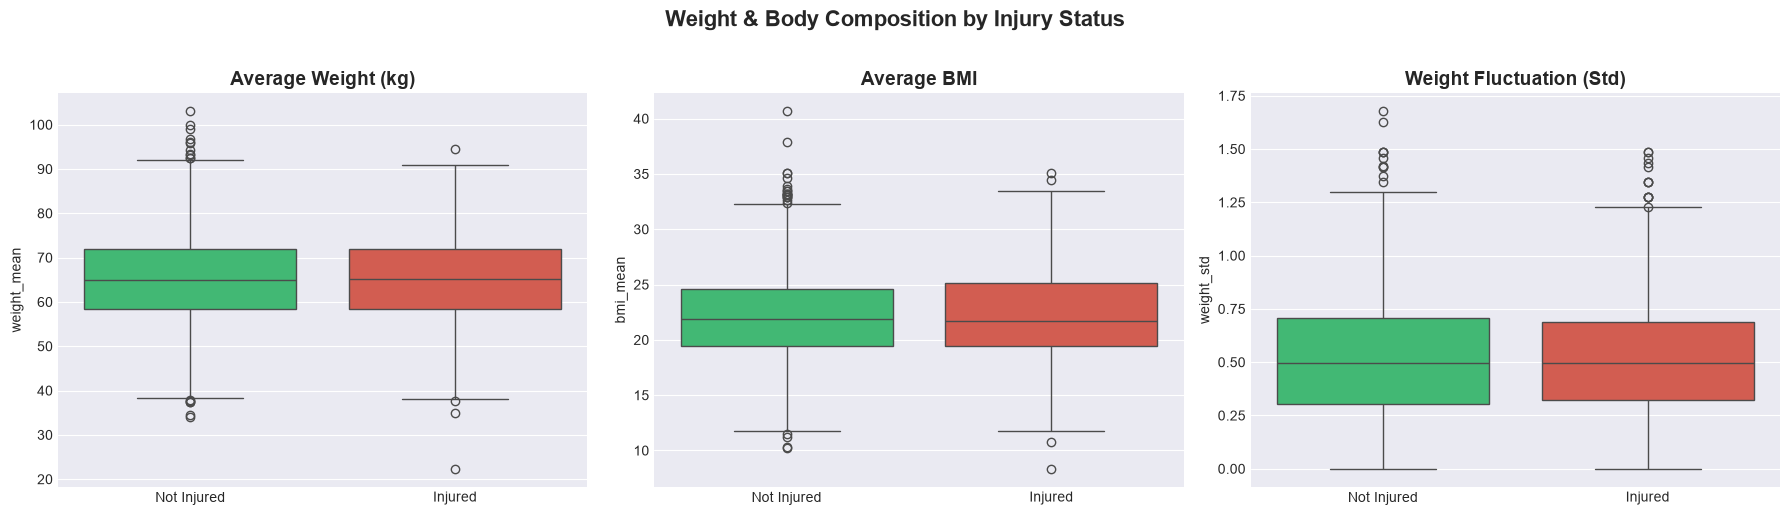


Weight data coverage: 2506 athletes have weight logs
Fat data available for: 2278 records


In [19]:
weight['Date'] = pd.to_datetime(weight['Date'])

weight_labeled = weight.merge(train_labels[['athlete_id', 'injured_in_risk_window']],
                               left_on='Id', right_on='athlete_id', how='inner')
weight_labeled['injury_label'] = weight_labeled['injured_in_risk_window'].map({0: 'Not Injured', 1: 'Injured'})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Weight distribution
weight_agg = weight_labeled.groupby(['Id', 'injury_label']).agg({
    'WeightKg': ['mean', 'std'],
    'BMI': 'mean',
    'Fat': 'mean'
}).reset_index()
weight_agg.columns = ['Id', 'injury_label', 'weight_mean', 'weight_std', 'bmi_mean', 'fat_mean']

sns.boxplot(x='injury_label', y='weight_mean', data=weight_agg, ax=axes[0],
           palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Average Weight (kg)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')

# BMI
sns.boxplot(x='injury_label', y='bmi_mean', data=weight_agg, ax=axes[1],
           palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Average BMI', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')

# Weight fluctuation (std)
sns.boxplot(x='injury_label', y='weight_std', data=weight_agg.dropna(subset=['weight_std']),
           ax=axes[2], palette=['#2ecc71', '#e74c3c'])
axes[2].set_title('Weight Fluctuation (Std)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('')

plt.suptitle('Weight & Body Composition by Injury Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nWeight data coverage: {weight_labeled["Id"].nunique()} athletes have weight logs')
print(f'Fat data available for: {weight_labeled["Fat"].notna().sum()} records')

---
## 🏋️‍♂️ 8. Training Sessions Analysis
---

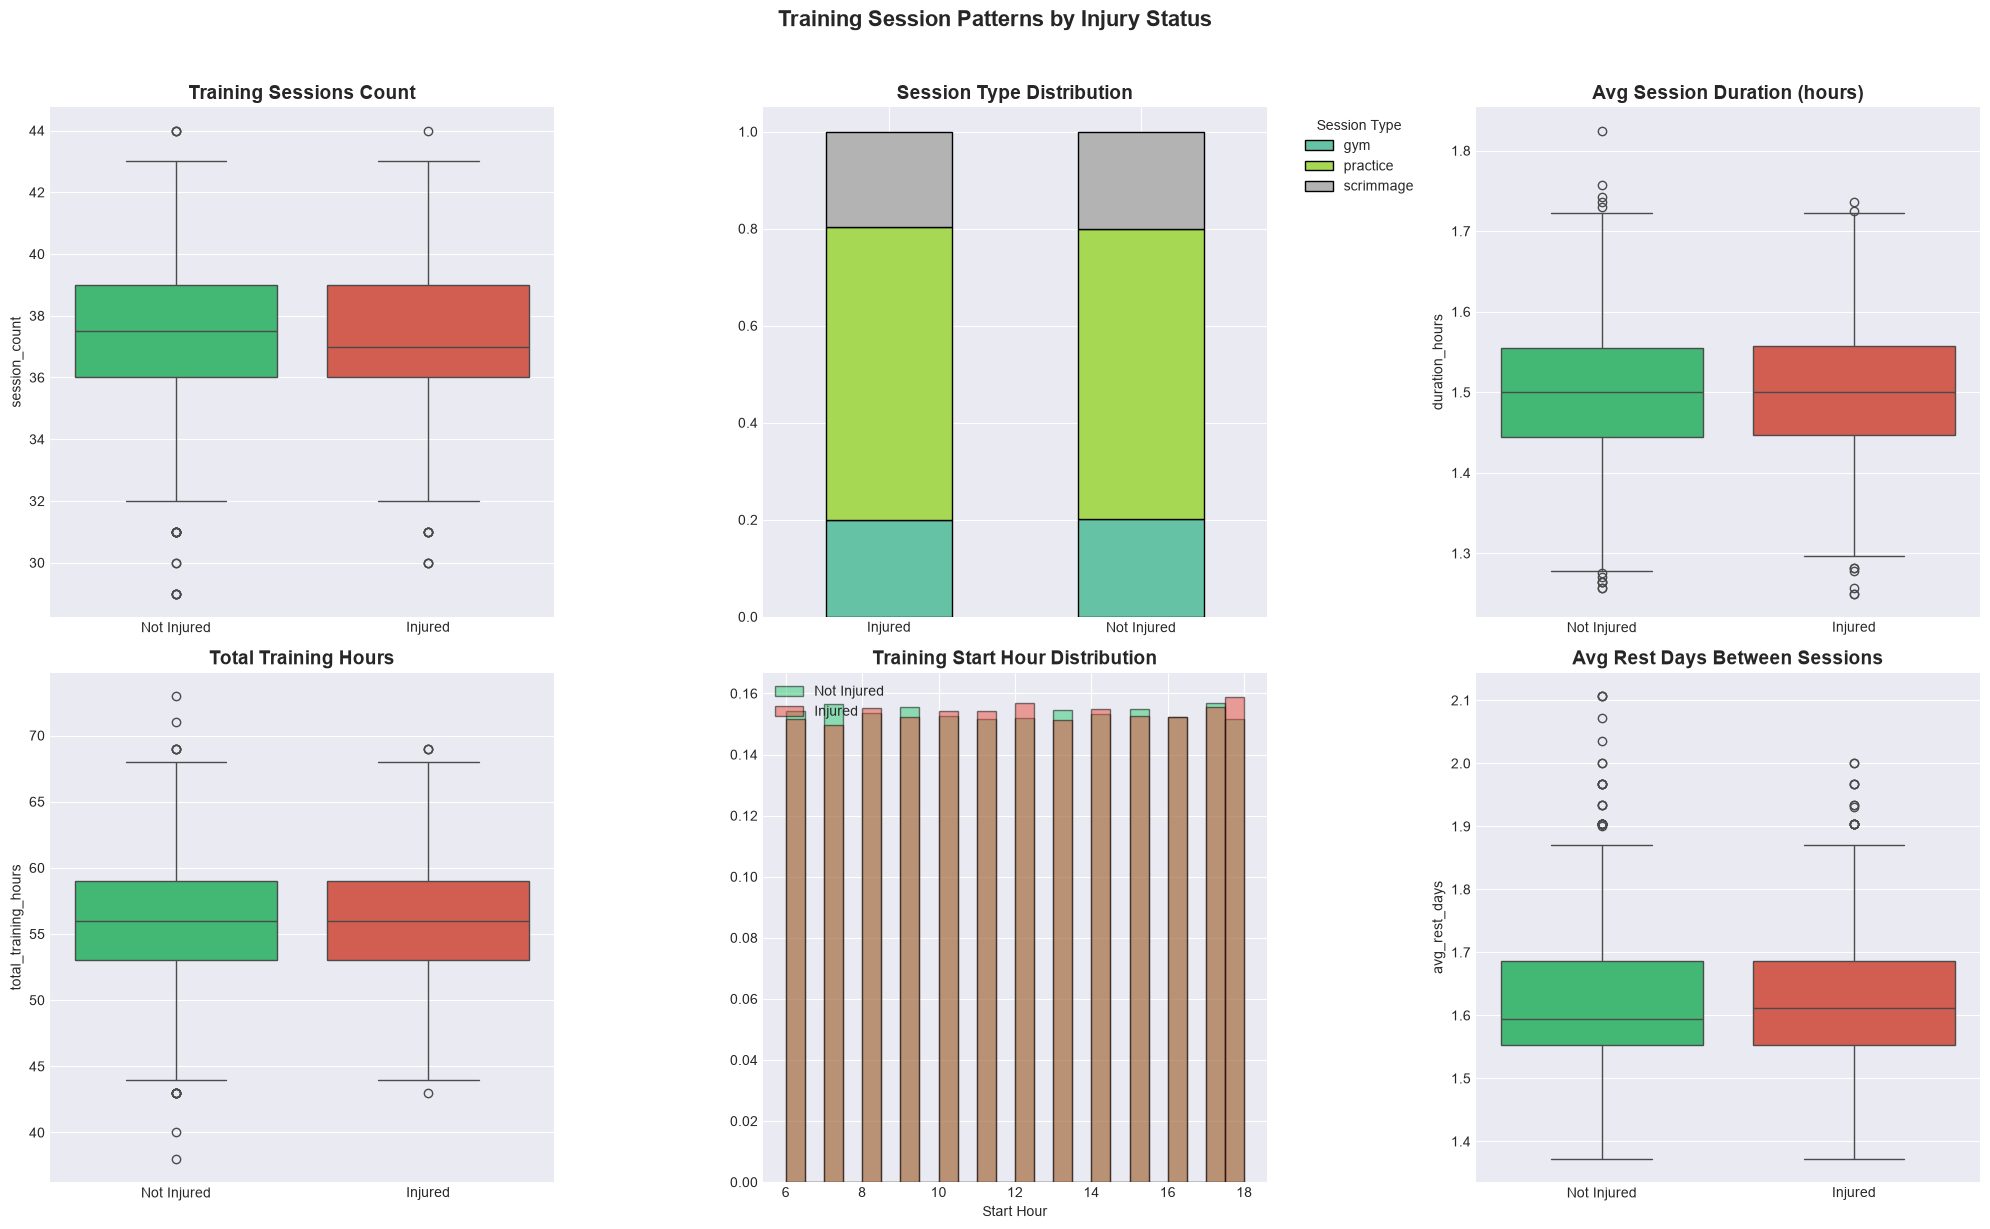

In [20]:
training_sessions['date'] = pd.to_datetime(training_sessions['date'])
training_sessions['duration_hours'] = training_sessions['end_hour'] - training_sessions['start_hour']

ts_labeled = training_sessions.merge(train_labels[['athlete_id', 'injured_in_risk_window']],
                                      on='athlete_id', how='inner')
ts_labeled['injury_label'] = ts_labeled['injured_in_risk_window'].map({0: 'Not Injured', 1: 'Injured'})

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Session count per athlete
session_counts = ts_labeled.groupby(['athlete_id', 'injury_label']).size().reset_index(name='session_count')
sns.boxplot(x='injury_label', y='session_count', data=session_counts, ax=axes[0, 0],
           palette=['#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Training Sessions Count', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('')

# Session type breakdown
type_counts = ts_labeled.groupby(['injury_label', 'sport_session_type']).size().reset_index(name='count')
type_pivot = type_counts.pivot(index='injury_label', columns='sport_session_type', values='count').fillna(0)
type_pivot_pct = type_pivot.div(type_pivot.sum(axis=1), axis=0)
type_pivot_pct.plot(kind='bar', stacked=True, ax=axes[0, 1], colormap='Set2', edgecolor='black')
axes[0, 1].set_title('Session Type Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('')
axes[0, 1].legend(title='Session Type', bbox_to_anchor=(1.05, 1))
axes[0, 1].tick_params(axis='x', rotation=0)

# Average session duration
dur_agg = ts_labeled.groupby(['athlete_id', 'injury_label'])['duration_hours'].mean().reset_index()
sns.boxplot(x='injury_label', y='duration_hours', data=dur_agg, ax=axes[0, 2],
           palette=['#2ecc71', '#e74c3c'])
axes[0, 2].set_title('Avg Session Duration (hours)', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('')

# Training load (total hours) per athlete
load = ts_labeled.groupby(['athlete_id', 'injury_label'])['duration_hours'].sum().reset_index()
load.columns = ['athlete_id', 'injury_label', 'total_training_hours']
sns.boxplot(x='injury_label', y='total_training_hours', data=load, ax=axes[1, 0],
           palette=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Total Training Hours', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('')

# Start hour distribution
for label, color in [('Not Injured', '#2ecc71'), ('Injured', '#e74c3c')]:
    subset = ts_labeled[ts_labeled['injury_label'] == label]
    axes[1, 1].hist(subset['start_hour'], bins=24, alpha=0.5, color=color,
                    label=label, edgecolor='black', density=True)
axes[1, 1].set_title('Training Start Hour Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Start Hour')
axes[1, 1].legend()

# Days between sessions (rest gaps)
ts_sorted = ts_labeled.sort_values(['athlete_id', 'date'])
ts_sorted['days_since_last'] = ts_sorted.groupby('athlete_id')['date'].diff().dt.days
rest_agg = ts_sorted.groupby(['athlete_id', 'injury_label'])['days_since_last'].agg(['mean', 'max']).reset_index()
rest_agg.columns = ['athlete_id', 'injury_label', 'avg_rest_days', 'max_rest_days']

sns.boxplot(x='injury_label', y='avg_rest_days', data=rest_agg, ax=axes[1, 2],
           palette=['#2ecc71', '#e74c3c'])
axes[1, 2].set_title('Avg Rest Days Between Sessions', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('')

plt.suptitle('Training Session Patterns by Injury Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

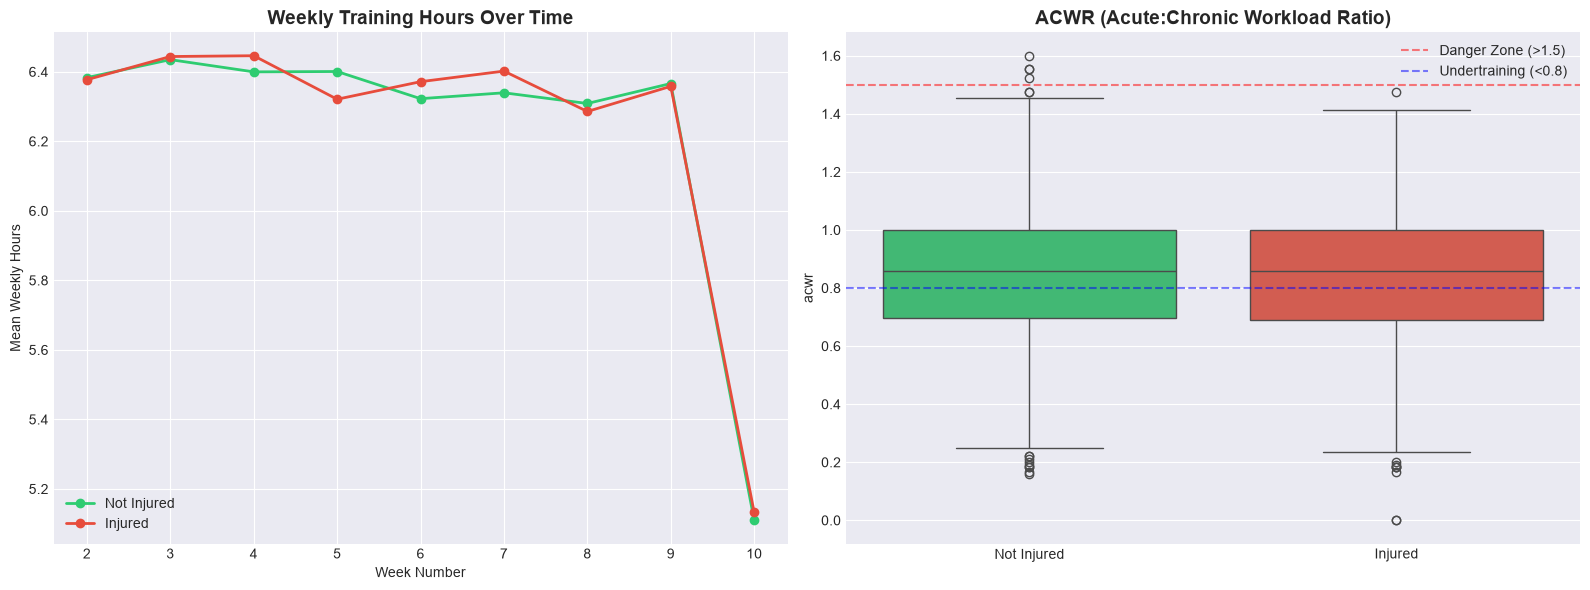

In [21]:
# Training intensity progression — weekly training load
ts_labeled['week_num'] = ts_labeled['date'].dt.isocalendar().week.astype(int)

weekly_load = ts_labeled.groupby(['athlete_id', 'injury_label', 'week_num']).agg({
    'duration_hours': 'sum',
    'session_id': 'count'
}).reset_index()
weekly_load.columns = ['athlete_id', 'injury_label', 'week_num', 'weekly_hours', 'weekly_sessions']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Weekly hours trend
for label, color in [('Not Injured', '#2ecc71'), ('Injured', '#e74c3c')]:
    subset = weekly_load[weekly_load['injury_label'] == label].groupby('week_num')['weekly_hours'].mean().reset_index()
    axes[0].plot(subset['week_num'], subset['weekly_hours'], 'o-', color=color,
                label=label, linewidth=2)
axes[0].set_title('Weekly Training Hours Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Week Number')
axes[0].set_ylabel('Mean Weekly Hours')
axes[0].legend()

# ACWR (Acute:Chronic Workload Ratio) proxy
# Compute rolling load ratios
athlete_weekly = weekly_load.pivot_table(index='athlete_id', columns='week_num',
                                         values='weekly_hours', fill_value=0)
weeks_avail = sorted(athlete_weekly.columns)
if len(weeks_avail) >= 4:
    last_week = weeks_avail[-1]
    acute = athlete_weekly[weeks_avail[-1]]
    chronic = athlete_weekly[weeks_avail[-4:]].mean(axis=1)
    acwr = acute / chronic.replace(0, np.nan)
    acwr_df = acwr.reset_index()
    acwr_df.columns = ['athlete_id', 'acwr']
    acwr_df = acwr_df.merge(train_labels[['athlete_id', 'injured_in_risk_window']], on='athlete_id', how='inner')
    acwr_df['injury_label'] = acwr_df['injured_in_risk_window'].map({0: 'Not Injured', 1: 'Injured'})
    
    sns.boxplot(x='injury_label', y='acwr', data=acwr_df.dropna(), ax=axes[1],
               palette=['#2ecc71', '#e74c3c'])
    axes[1].axhline(y=1.5, color='red', linestyle='--', alpha=0.5, label='Danger Zone (>1.5)')
    axes[1].axhline(y=0.8, color='blue', linestyle='--', alpha=0.5, label='Undertraining (<0.8)')
    axes[1].set_title('ACWR (Acute:Chronic Workload Ratio)', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

---
## 🔗 9. Cross-Dataset Correlation Analysis
---

In [22]:
# Build a consolidated per-athlete feature matrix for correlation analysis

# Daily activity aggregates
daily_agg = daily_activity.groupby('Id').agg({
    'TotalSteps': ['mean', 'std', 'min', 'max'],
    'TotalDistance': ['mean', 'std'],
    'VeryActiveMinutes': ['mean', 'std', 'sum'],
    'FairlyActiveMinutes': ['mean', 'sum'],
    'LightlyActiveMinutes': ['mean'],
    'SedentaryMinutes': ['mean', 'std'],
    'Calories': ['mean', 'std']
}).reset_index()
daily_agg.columns = ['_'.join(col).strip('_') for col in daily_agg.columns]

# Sleep aggregates
sleep['hours_asleep'] = sleep['TotalMinutesAsleep'] / 60
sleep['sleep_efficiency'] = sleep['TotalMinutesAsleep'] / sleep['TotalTimeInBed']
sleep_agg2 = sleep.groupby('Id').agg({
    'hours_asleep': ['mean', 'std'],
    'sleep_efficiency': ['mean'],
    'TotalSleepRecords': ['mean']
}).reset_index()
sleep_agg2.columns = ['_'.join(col).strip('_') for col in sleep_agg2.columns]

# Heart rate aggregates
hr_agg = hourly_heartrate.groupby('Id').agg({
    'AvgHeartRate': ['mean', 'std', 'min', 'max'],
    'MaxHeartRate': ['mean', 'max'],
    'MinHeartRate': ['mean', 'min']
}).reset_index()
hr_agg.columns = ['_'.join(col).strip('_') for col in hr_agg.columns]

# Training session aggregates
training_sessions['duration_hours'] = training_sessions['end_hour'] - training_sessions['start_hour']
ts_agg = training_sessions.groupby('athlete_id').agg({
    'session_id': 'count',
    'duration_hours': ['mean', 'sum', 'std'],
    'start_hour': ['mean', 'std']
}).reset_index()
ts_agg.columns = ['athlete_id'] + ['ts_' + '_'.join(col).strip('_') for col in ts_agg.columns[1:]]

# Merge all
feature_matrix = athlete_meta.merge(train_labels, on='athlete_id', how='inner')
feature_matrix = feature_matrix.merge(daily_agg, left_on='athlete_id', right_on='Id', how='left').drop('Id', axis=1, errors='ignore')
feature_matrix = feature_matrix.merge(sleep_agg2, left_on='athlete_id', right_on='Id', how='left').drop('Id', axis=1, errors='ignore')
feature_matrix = feature_matrix.merge(hr_agg, left_on='athlete_id', right_on='Id', how='left').drop('Id', axis=1, errors='ignore')
feature_matrix = feature_matrix.merge(ts_agg, on='athlete_id', how='left')

print(f'Consolidated feature matrix: {feature_matrix.shape}')
display(feature_matrix.head())

Consolidated feature matrix: (3000, 48)


,athlete_id,sport,age,gender,height_cm,weight_kg_baseline,dominant_side,years_playing,position,team_id,prior_season_injury_count,injured_in_risk_window,onset_day_offset,recovery_duration,TotalSteps_mean,TotalSteps_std,TotalSteps_min,TotalSteps_max,TotalDistance_mean,TotalDistance_std,VeryActiveMinutes_mean,VeryActiveMinutes_std,VeryActiveMinutes_sum,FairlyActiveMinutes_mean,FairlyActiveMinutes_sum,LightlyActiveMinutes_mean,SedentaryMinutes_mean,SedentaryMinutes_std,Calories_mean,Calories_std,hours_asleep_mean,hours_asleep_std,sleep_efficiency_mean,TotalSleepRecords_mean,AvgHeartRate_mean,AvgHeartRate_std,AvgHeartRate_min,AvgHeartRate_max,MaxHeartRate_mean,MaxHeartRate_max,MinHeartRate_mean,MinHeartRate_min,ts_session_id_count,ts_duration_hours_mean,ts_duration_hours_sum,ts_duration_hours_std,ts_start_hour_mean,ts_start_hour_std
0,1,Football,24,male,183.0,74.0,right,5,Goalkeeper,FOO-3,1,0,NaN,NaN,8219.466667,2392.482885,4197,15632,6.164500,1.794125,23.416667,7.237594,1405,13.666667,820,202.816667,1200.0,0.0,2110.700000,149.148805,7.641667,0.185934,0.903468,1.0,88.019651,17.558237,58,152,94.557496,159,84.513100,53,35,1.514286,53,0.507093,11.914286,3.665189
1,2,Athletics,20,female,165.3,56.0,right,6,Throws,ATH-2,1,1,23.0,10.0,5162.450000,3015.357310,253,14653,3.871667,2.261981,27.000000,17.442399,1620,16.050000,963,196.933333,1200.0,0.0,2016.566667,249.484646,6.970556,0.424800,0.868940,1.0,89.854136,23.517537,55,170,96.373004,173,86.373730,51,38,1.552632,59,0.503897,12.789474,3.059393
2,3,Tennis,18,male,186.1,50.4,right,5,Singles,TEN-5,1,0,NaN,NaN,10424.183333,2632.346169,5895,19701,7.818167,1.974944,23.700000,6.426376,1422,13.983333,839,202.366667,1200.0,0.0,2200.766667,150.998301,6.963056,0.178324,0.905167,1.0,88.031227,17.004310,59,151,94.529412,161,84.526507,55,40,1.500000,60,0.506370,11.775000,3.951550
3,4,Football,22,female,163.3,49.3,right,4,Forward,FOO-2,0,1,22.0,15.0,9773.433333,6112.123203,232,26964,7.330167,4.584438,25.450000,15.879232,1527,15.850000,951,198.683333,1200.0,0.0,2191.433333,365.378762,5.991389,0.334637,0.866282,1.0,89.797101,23.139317,52,167,96.336232,176,86.272464,48,35,1.457143,51,0.505433,12.000000,3.880570
4,5,Tennis,22,male,157.3,55.2,right,11,Singles,TEN-3,0,0,NaN,NaN,9745.800000,2158.023647,5659,12595,7.309167,1.618510,23.033333,5.442976,1382,13.683333,821,203.250000,1200.0,0.0,2169.100000,125.083118,7.151667,0.156489,0.900351,1.0,91.642547,16.255282,63,125,98.112156,133,88.138929,58,36,1.388889,50,0.494413,11.555556,3.605111


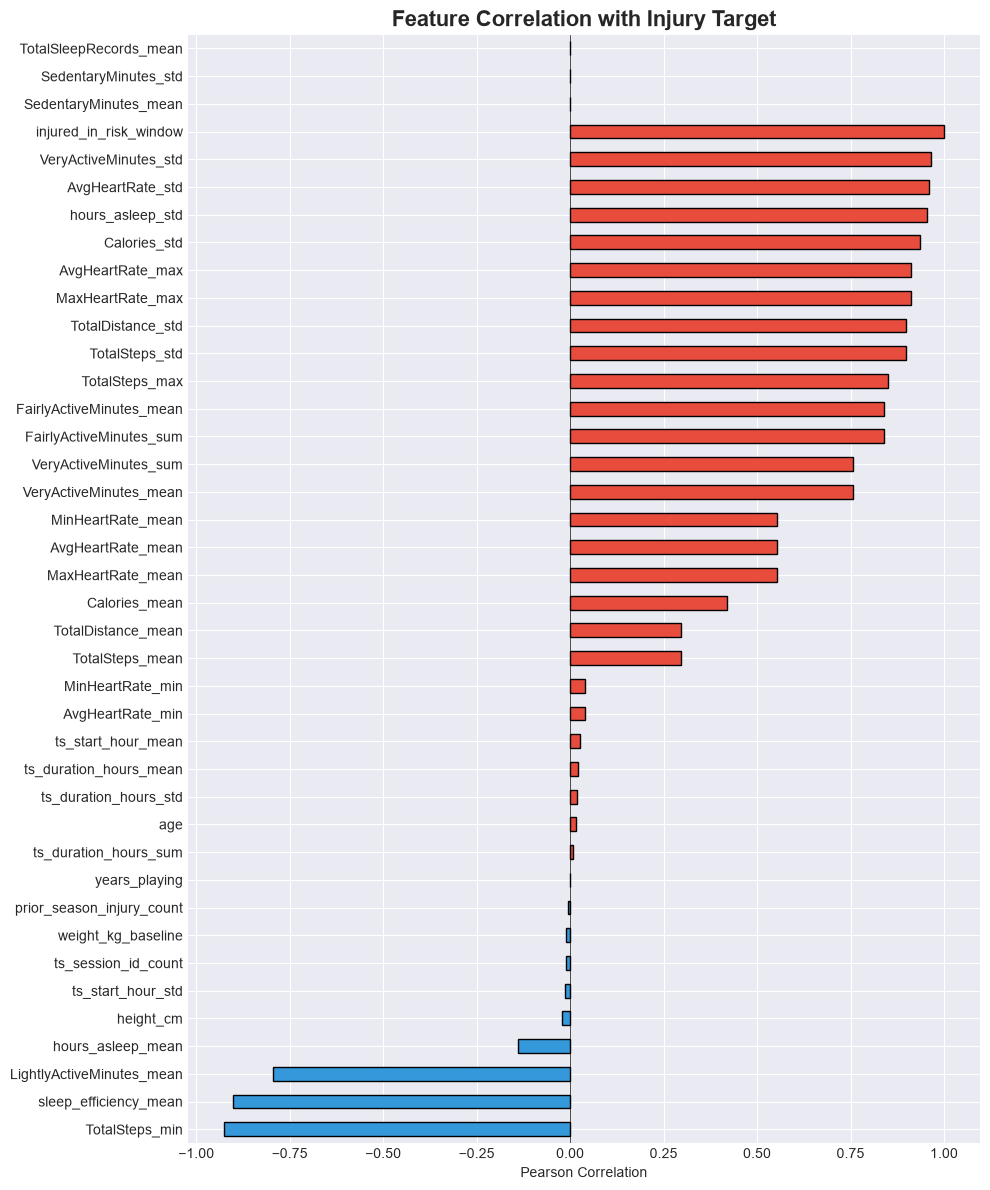

In [23]:
# Correlation heatmap with target
numeric_cols = feature_matrix.select_dtypes(include=[np.number]).columns.tolist()
# Remove IDs and targets from features for correlation
exclude = ['athlete_id', 'onset_day_offset', 'recovery_duration']
feat_cols = [c for c in numeric_cols if c not in exclude]

corr_with_target = feature_matrix[feat_cols].corrwith(feature_matrix['injured_in_risk_window']).sort_values()

fig, ax = plt.subplots(figsize=(10, max(12, len(corr_with_target) * 0.3)))
colors_corr = ['#e74c3c' if v > 0 else '#3498db' for v in corr_with_target]
corr_with_target.plot(kind='barh', ax=ax, color=colors_corr, edgecolor='black')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_title('Feature Correlation with Injury Target', fontsize=16, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

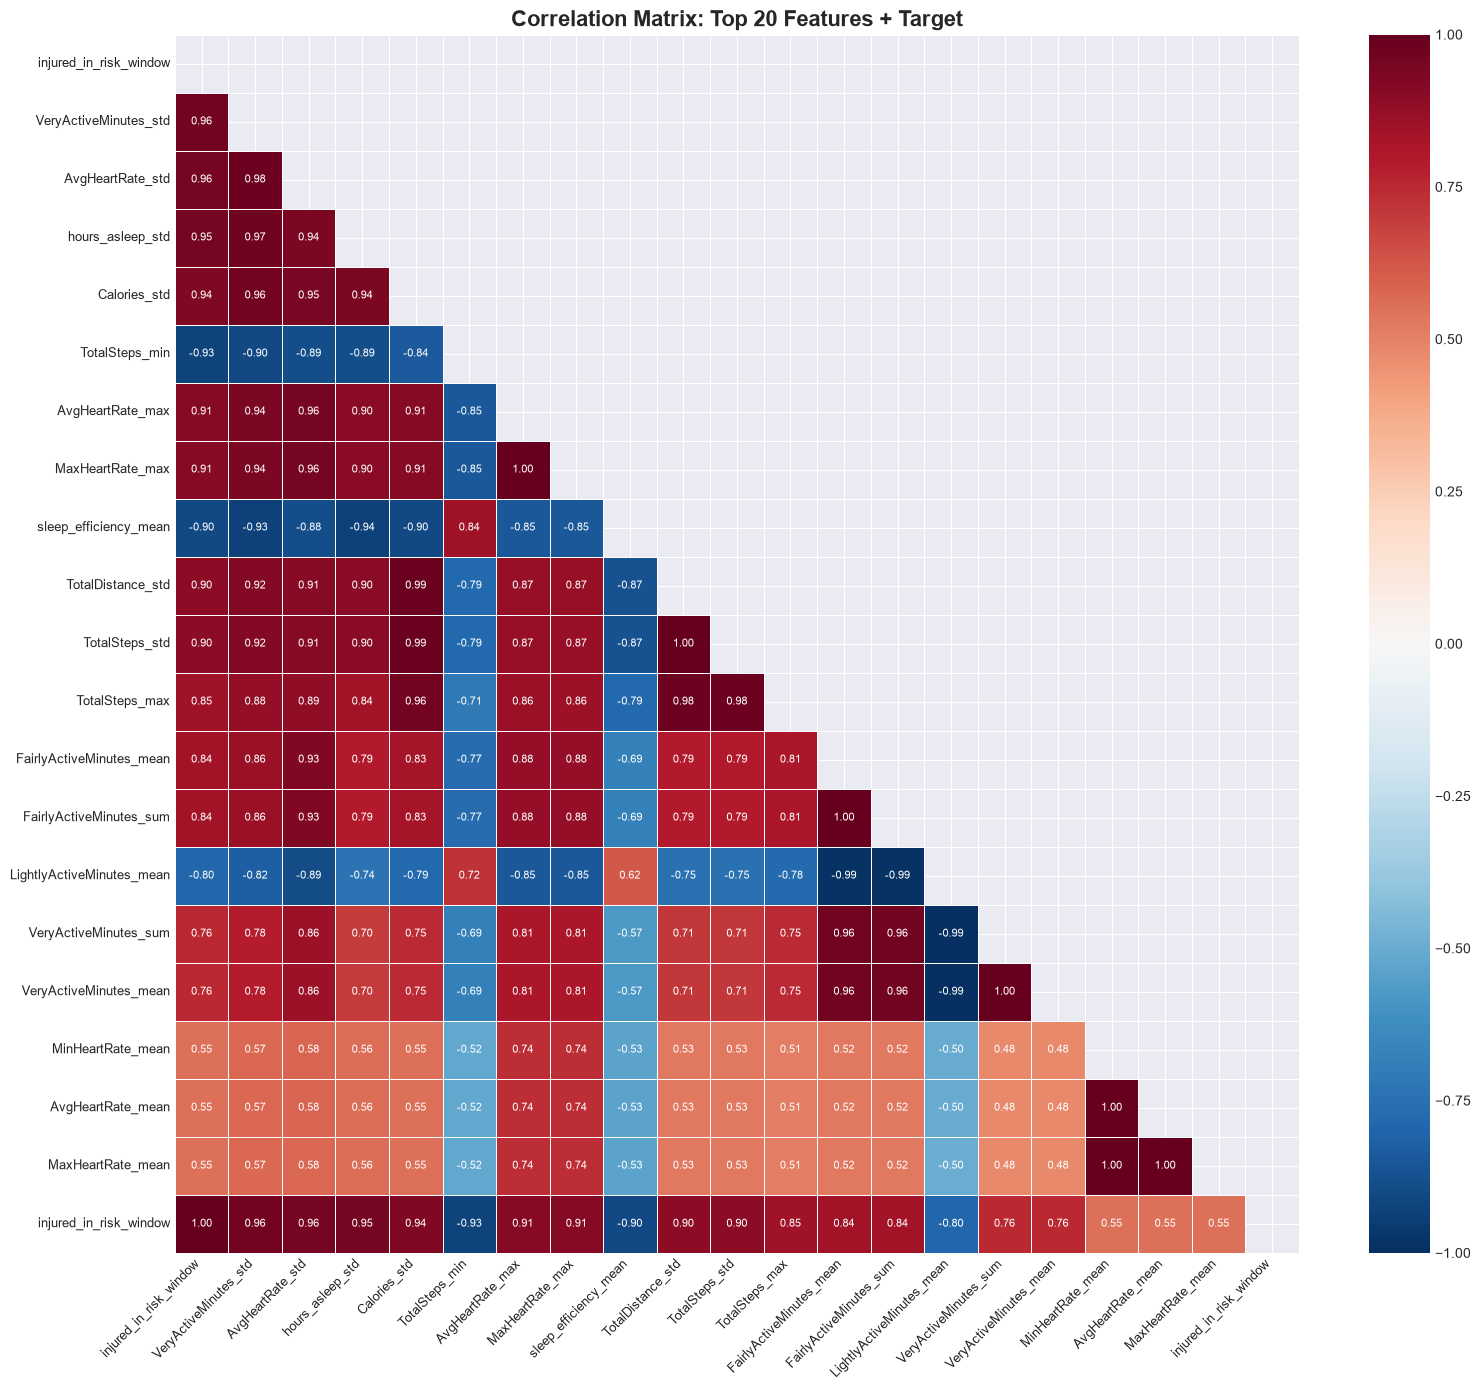

In [24]:
# Inter-feature correlation matrix (top features only)
top_features = corr_with_target.abs().nlargest(20).index.tolist()
top_features_with_target = top_features + ['injured_in_risk_window']

corr_matrix = feature_matrix[top_features_with_target].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
           center=0, ax=ax, linewidths=0.5, vmin=-1, vmax=1,
           annot_kws={'size': 8})
ax.set_title('Correlation Matrix: Top 20 Features + Target', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

---
## 🧠 10. Advanced EDA: Mutual Information, PCA, t-SNE, Clustering
---

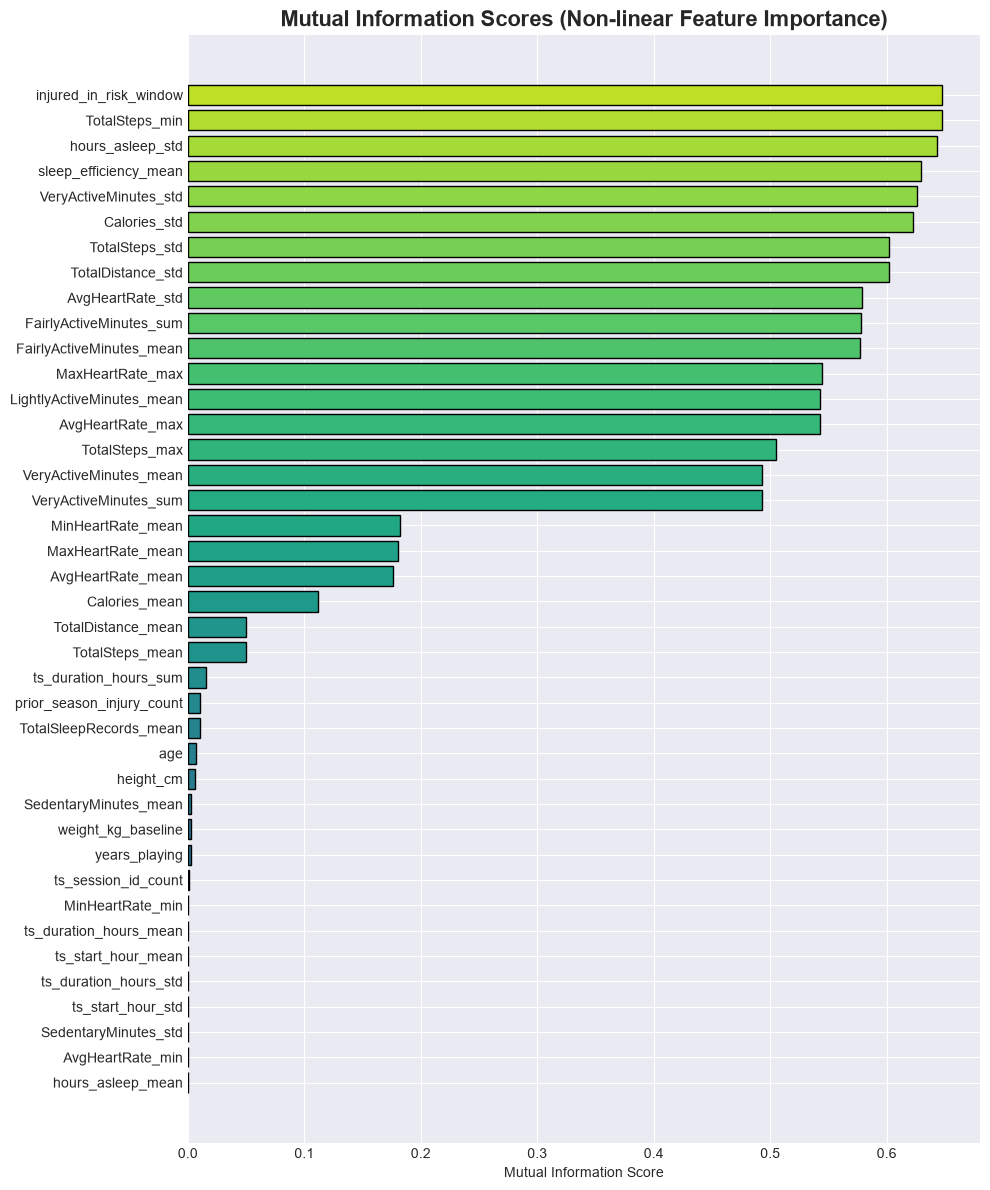

In [25]:
# Mutual Information for feature importance (captures non-linear relationships)
from sklearn.impute import SimpleImputer

# Prepare data
numeric_features = feature_matrix[feat_cols].copy()
# Remove columns with all NaN
numeric_features = numeric_features.dropna(axis=1, how='all')

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(numeric_features),
                          columns=numeric_features.columns)
y = feature_matrix['injured_in_risk_window'].values

# Mutual Information
mi_scores = mutual_info_classif(X_imputed, y, random_state=42, n_neighbors=5)
mi_df = pd.DataFrame({'feature': numeric_features.columns, 'mi_score': mi_scores})
mi_df = mi_df.sort_values('mi_score', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(12, len(mi_df) * 0.3)))
colors_mi = plt.cm.viridis(np.linspace(0.2, 0.9, len(mi_df)))
ax.barh(mi_df['feature'], mi_df['mi_score'], color=colors_mi, edgecolor='black')
ax.set_title('Mutual Information Scores (Non-linear Feature Importance)', fontsize=16, fontweight='bold')
ax.set_xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()

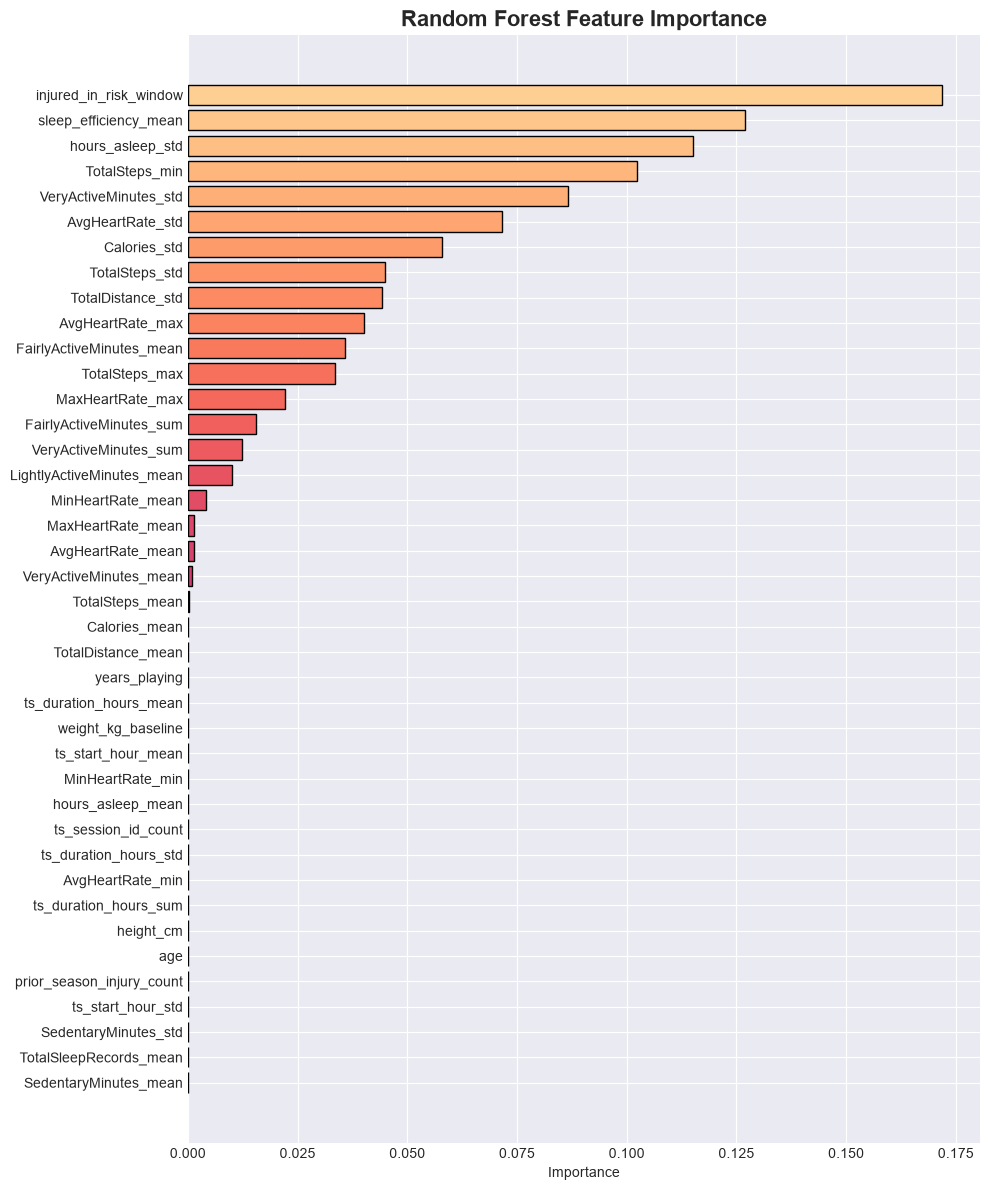

In [26]:
# Random Forest Feature Importance
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, max_depth=10)
rf.fit(X_imputed, y)

rf_imp = pd.DataFrame({'feature': numeric_features.columns, 'importance': rf.feature_importances_})
rf_imp = rf_imp.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(12, len(rf_imp) * 0.3)))
colors_rf = plt.cm.magma(np.linspace(0.2, 0.9, len(rf_imp)))
ax.barh(rf_imp['feature'], rf_imp['importance'], color=colors_rf, edgecolor='black')
ax.set_title('Random Forest Feature Importance', fontsize=16, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [27]:
# Combined ranking: Pearson + MI + RF
combined_ranking = pd.DataFrame({
    'feature': numeric_features.columns,
    'pearson_abs': corr_with_target.reindex(numeric_features.columns).abs().values,
    'mi_score': mi_scores,
    'rf_importance': rf.feature_importances_
})

# Rank each method (lower rank = more important)
for col in ['pearson_abs', 'mi_score', 'rf_importance']:
    combined_ranking[f'{col}_rank'] = combined_ranking[col].rank(ascending=False)

combined_ranking['avg_rank'] = combined_ranking[['pearson_abs_rank', 'mi_score_rank', 'rf_importance_rank']].mean(axis=1)
combined_ranking = combined_ranking.sort_values('avg_rank')

print('🏆 Top 20 Features by Combined Ranking (Pearson + MI + RF):')
display(combined_ranking[['feature', 'pearson_abs', 'mi_score', 'rf_importance', 'avg_rank']].head(20))

🏆 Top 20 Features by Combined Ranking (Pearson + MI + RF):


,feature,pearson_abs,mi_score,rf_importance,avg_rank
5,injured_in_risk_window,1.000000,0.647697,0.171905,1.000000
23,hours_asleep_std,0.953272,0.642895,0.115037,3.333333
13,VeryActiveMinutes_std,0.964929,0.626171,0.086609,4.000000
8,TotalSteps_min,0.926245,0.647613,0.102333,4.000000
24,sleep_efficiency_mean,0.901315,0.629758,0.126858,5.000000
27,AvgHeartRate_std,0.959050,0.579120,0.071527,6.000000
21,Calories_std,0.936139,0.622936,0.057838,6.000000
7,TotalSteps_std,0.897469,0.601568,0.044873,8.666667
11,TotalDistance_std,0.897473,0.601566,0.044321,9.000000
29,AvgHeartRate_max,0.913007,0.542403,0.040169,10.333333


Components needed for 95% variance: 14


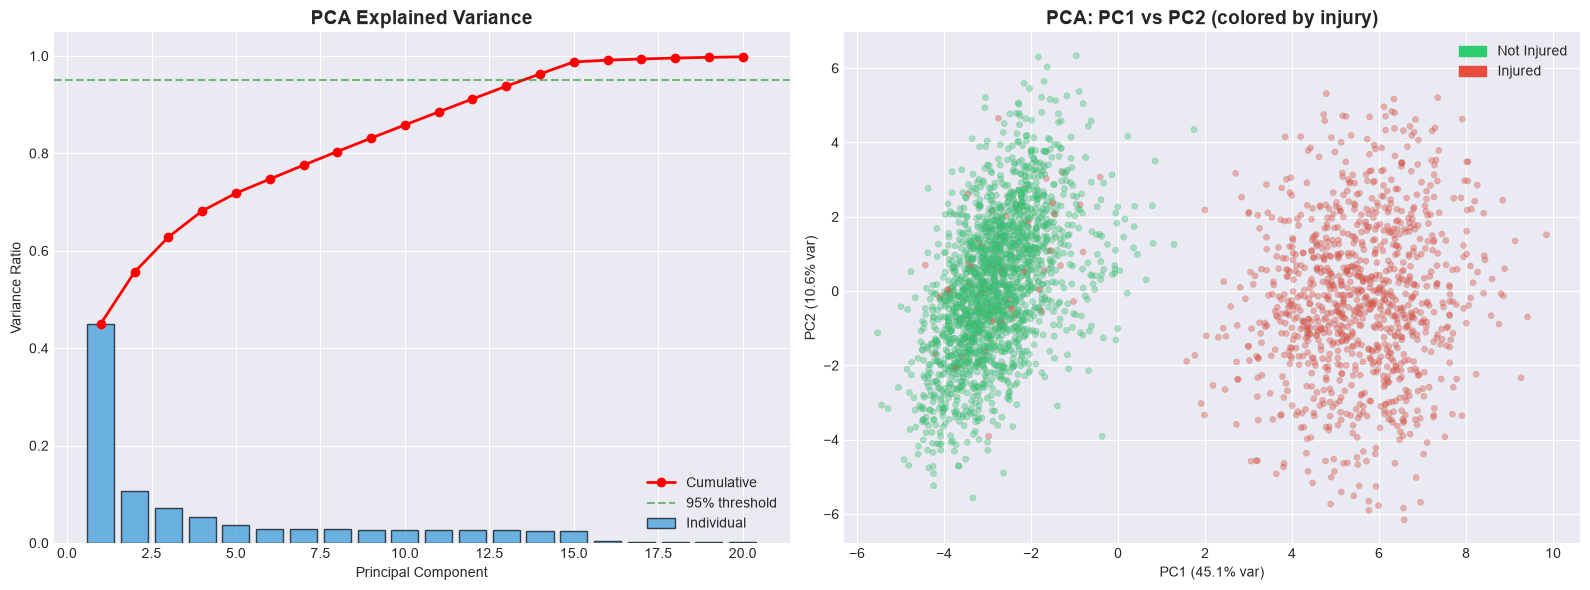

In [28]:
# PCA Analysis
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

pca = PCA(n_components=min(20, X_scaled.shape[1]))
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Explained variance
cumvar = np.cumsum(pca.explained_variance_ratio_)
axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_,
           alpha=0.7, color='#3498db', edgecolor='black', label='Individual')
axes[0].plot(range(1, len(cumvar)+1), cumvar, 'ro-', linewidth=2, label='Cumulative')
axes[0].axhline(y=0.95, color='green', linestyle='--', alpha=0.5, label='95% threshold')
axes[0].set_title('PCA Explained Variance', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Ratio')
axes[0].legend()

n_95 = np.argmax(cumvar >= 0.95) + 1
print(f'Components needed for 95% variance: {n_95}')

# PCA scatter (first 2 components)
colors_pca = ['#2ecc71' if label == 0 else '#e74c3c' for label in y]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_pca, alpha=0.4, s=20, edgecolors='gray', linewidths=0.3)
axes[1].set_title('PCA: PC1 vs PC2 (colored by injury)', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color='#2ecc71', label='Not Injured'), Patch(color='#e74c3c', label='Injured')])

plt.tight_layout()
plt.show()

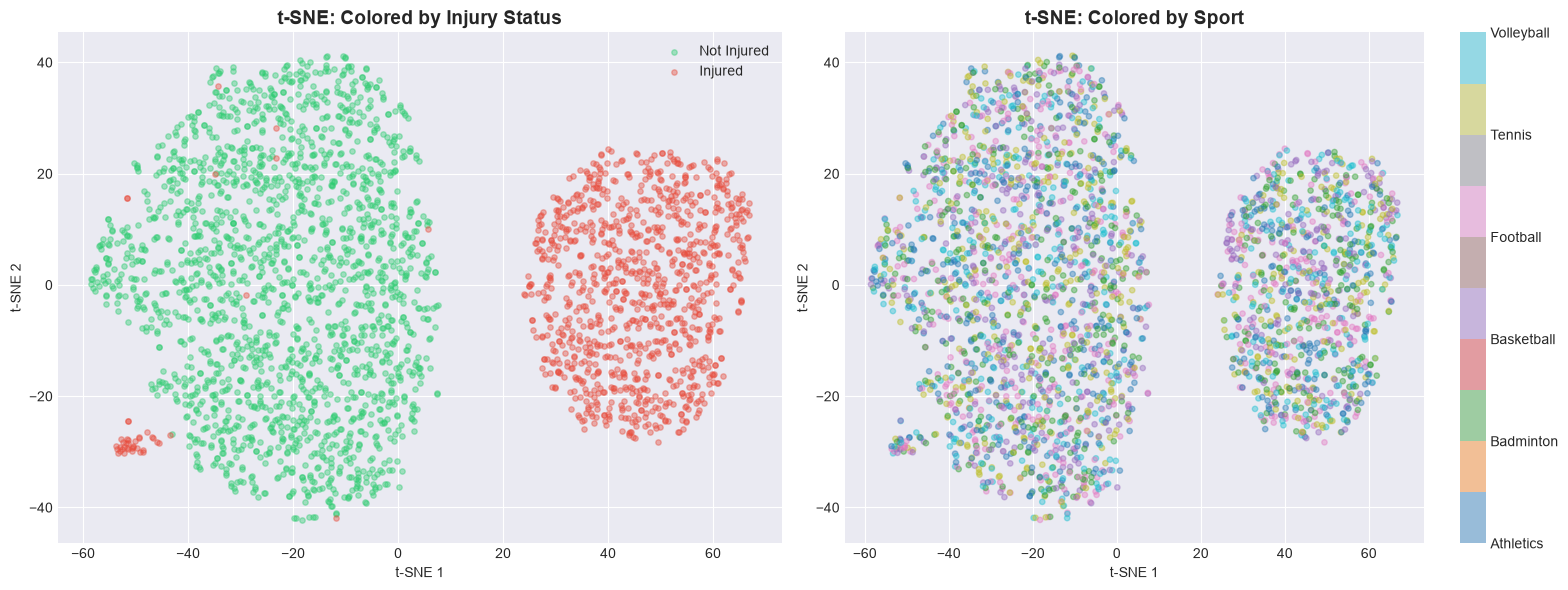

In [30]:
# t-SNE for non-linear dimensionality reduction
from sklearn.manifold import TSNE

# Use PCA-reduced data for speed
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    max_iter=1000
)

X_tsne = tsne.fit_transform(
    X_pca[:, :min(10, X_pca.shape[1])]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colored by injury
for label, color, name in [
    (0, '#2ecc71', 'Not Injured'),
    (1, '#e74c3c', 'Injured')
]:
    mask = y == label
    axes[0].scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        c=color,
        alpha=0.4,
        s=15,
        label=name
    )

axes[0].set_title(
    't-SNE: Colored by Injury Status',
    fontsize=14,
    fontweight='bold'
)
axes[0].legend()
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')


# Colored by sport
le_sport = LabelEncoder()
sport_encoded = le_sport.fit_transform(feature_matrix['sport'])

scatter = axes[1].scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=sport_encoded,
    cmap='tab10',
    alpha=0.4,
    s=15
)

axes[1].set_title(
    't-SNE: Colored by Sport',
    fontsize=14,
    fontweight='bold'
)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_ticks(range(len(le_sport.classes_)))
cbar.set_ticklabels(le_sport.classes_)

plt.tight_layout()
plt.show()

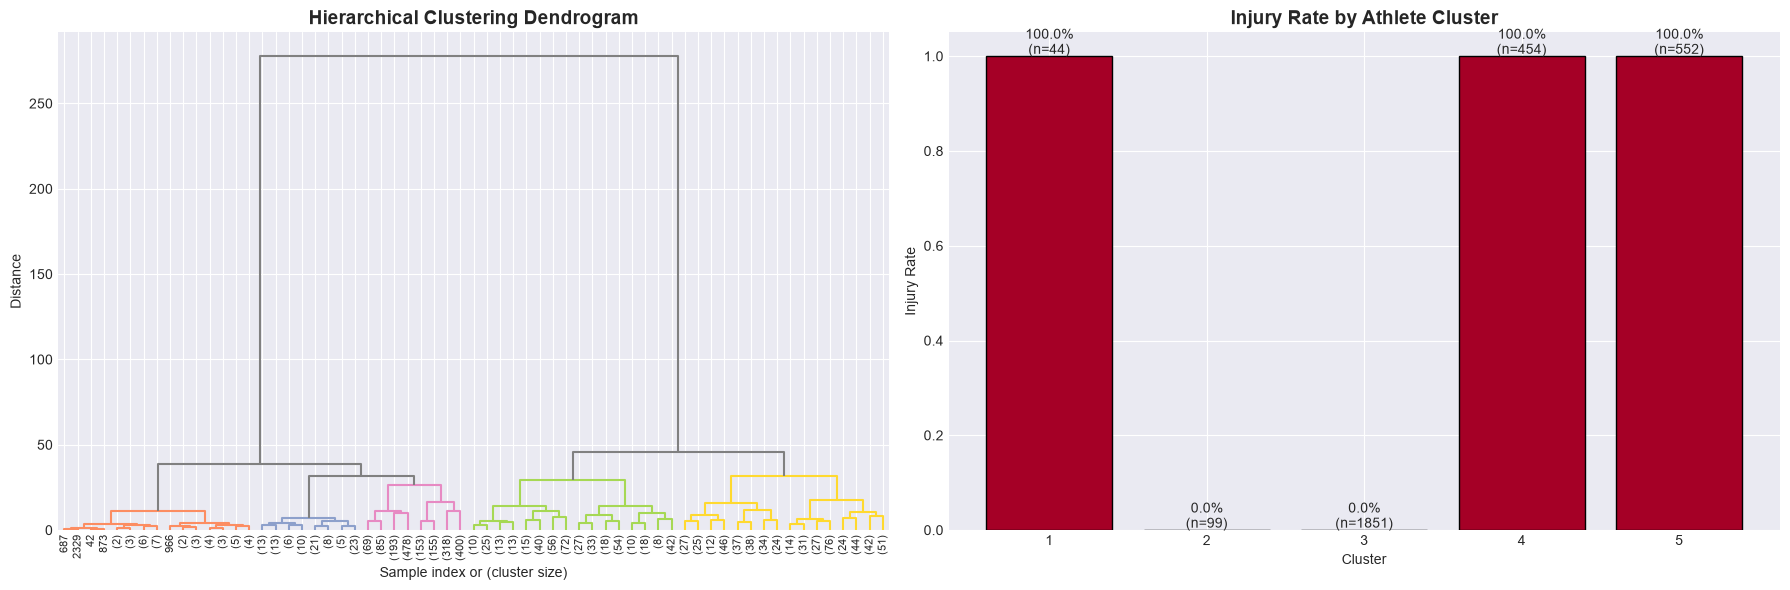

In [31]:
# Hierarchical Clustering on athlete profiles
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Use top features for clustering
top_feat_names = combined_ranking['feature'].head(15).tolist()
X_cluster = X_imputed[top_feat_names].copy()
X_cluster_scaled = StandardScaler().fit_transform(X_cluster)

# Linkage
Z = linkage(X_cluster_scaled, method='ward')

# Find optimal clusters
clusters = fcluster(Z, t=5, criterion='maxclust')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Dendrogram (truncated)
dendrogram(Z, truncate_mode='level', p=5, ax=axes[0], color_threshold=Z[-4, 2],
          above_threshold_color='gray', leaf_font_size=8)
axes[0].set_title('Hierarchical Clustering Dendrogram', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sample index or (cluster size)')
axes[0].set_ylabel('Distance')

# Injury rate by cluster
cluster_df = pd.DataFrame({'cluster': clusters, 'injured': y})
cluster_injury = cluster_df.groupby('cluster')['injured'].agg(['mean', 'count']).reset_index()
cluster_injury.columns = ['cluster', 'injury_rate', 'count']

bars = axes[1].bar(cluster_injury['cluster'], cluster_injury['injury_rate'],
                   color=plt.cm.RdYlGn_r(cluster_injury['injury_rate']), edgecolor='black')
for bar, rate, count in zip(bars, cluster_injury['injury_rate'], cluster_injury['count']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{rate:.1%}\n(n={count})', ha='center', fontsize=10)
axes[1].set_title('Injury Rate by Athlete Cluster', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Injury Rate')

plt.tight_layout()
plt.show()

---
## 📊 11. Advanced Statistical Tests & Distributions
---

In [32]:
# Statistical significance tests across all numeric features
results = []
for col in numeric_features.columns:
    group0 = X_imputed.loc[y == 0, col]
    group1 = X_imputed.loc[y == 1, col]
    
    # Mann-Whitney U test (non-parametric)
    try:
        stat_mw, p_mw = stats.mannwhitneyu(group0, group1, alternative='two-sided')
    except:
        p_mw = np.nan
    
    # Kolmogorov-Smirnov test
    try:
        stat_ks, p_ks = stats.ks_2samp(group0, group1)
    except:
        p_ks = np.nan
    
    # Effect size (Cohen's d)
    pooled_std = np.sqrt((group0.std()**2 + group1.std()**2) / 2)
    cohens_d = (group1.mean() - group0.mean()) / pooled_std if pooled_std > 0 else 0
    
    results.append({
        'feature': col,
        'p_mannwhitney': p_mw,
        'p_ks': p_ks,
        'cohens_d': cohens_d,
        'mean_not_injured': group0.mean(),
        'mean_injured': group1.mean()
    })

stat_results = pd.DataFrame(results)
stat_results['significant_mw'] = stat_results['p_mannwhitney'] < 0.05
stat_results = stat_results.sort_values('p_mannwhitney')

print(f'\n📊 Statistically significant features (p < 0.05): {stat_results["significant_mw"].sum()} / {len(stat_results)}')
print(f'\nTop 20 most significant features:')
display(stat_results.head(20))


📊 Statistically significant features (p < 0.05): 24 / 40

Top 20 most significant features:


,feature,p_mannwhitney,p_ks,cohens_d,mean_not_injured,mean_injured,significant_mw
7,TotalSteps_std,0.000000e+00,0.000000e+00,3.651833,1726.255937,6065.904259,True
5,injured_in_risk_window,0.000000e+00,0.000000e+00,0.000000,0.000000,1.000000,True
13,VeryActiveMinutes_std,0.000000e+00,0.000000e+00,6.562280,5.474334,17.055315,True
14,VeryActiveMinutes_sum,0.000000e+00,8.399116e-323,2.100415,1343.337949,1539.756190,True
12,VeryActiveMinutes_mean,0.000000e+00,8.399116e-323,2.100415,22.388966,25.662603,True
11,TotalDistance_std,0.000000e+00,0.000000e+00,3.651907,1.294691,4.549442,True
9,TotalSteps_max,0.000000e+00,0.000000e+00,2.976449,10561.374359,26312.404762,True
8,TotalSteps_min,0.000000e+00,0.000000e+00,-5.822682,4778.233846,370.346667,True
15,FairlyActiveMinutes_mean,0.000000e+00,0.000000e+00,2.803064,13.428855,15.773492,True
29,AvgHeartRate_max,0.000000e+00,0.000000e+00,4.534096,115.095385,166.079048,True


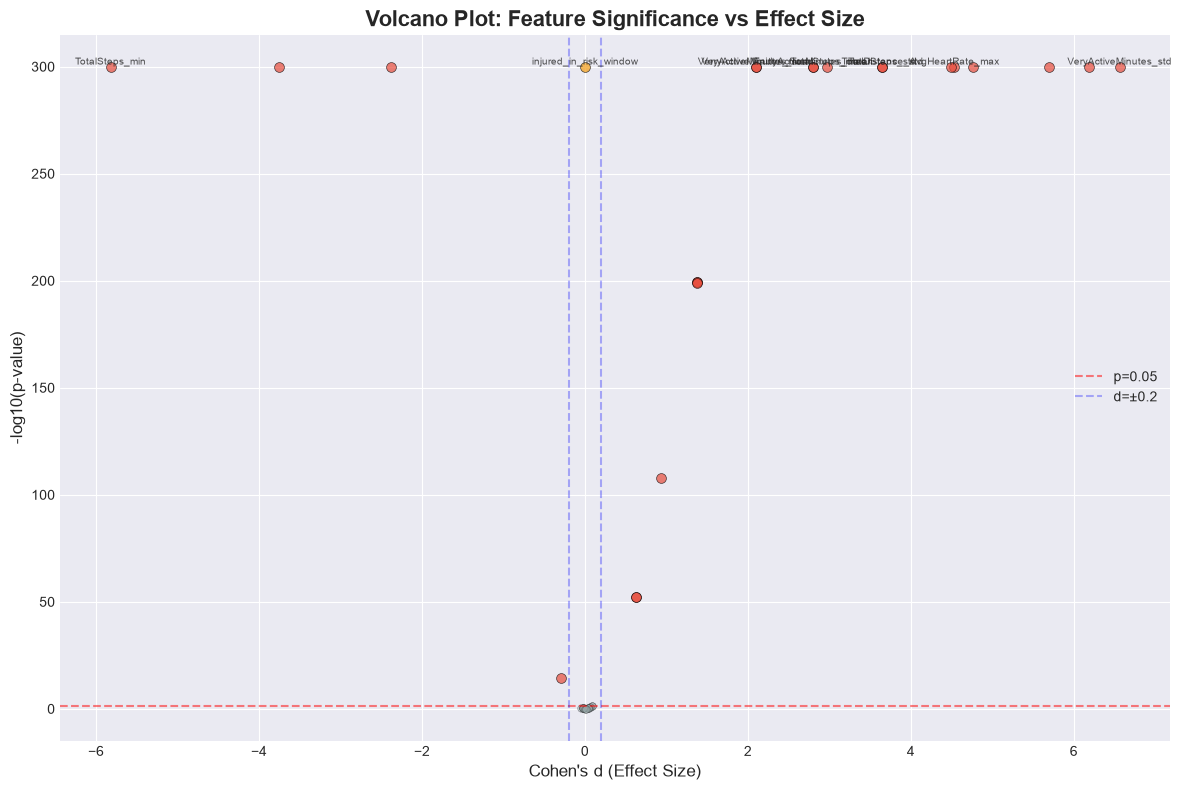

In [33]:
# Volcano plot — Effect size vs Significance
fig, ax = plt.subplots(figsize=(12, 8))

stat_results['neg_log_p'] = -np.log10(stat_results['p_mannwhitney'].clip(lower=1e-300))

# Color by significance + effect size
conditions = [
    (stat_results['p_mannwhitney'] < 0.05) & (stat_results['cohens_d'].abs() > 0.2),
    (stat_results['p_mannwhitney'] < 0.05),
]
colors_volcano = ['#e74c3c', '#f39c12']
default_color = '#95a5a6'

for i, (condition, color) in enumerate(zip(conditions, colors_volcano)):
    subset = stat_results[condition & ~stat_results.index.isin(
        stat_results[conditions[0]].index if i > 0 else [])]
    ax.scatter(subset['cohens_d'], subset['neg_log_p'], c=color, alpha=0.7, s=50, edgecolors='black', linewidths=0.5)

# Non-significant
ns = stat_results[stat_results['p_mannwhitney'] >= 0.05]
ax.scatter(ns['cohens_d'], ns['neg_log_p'], c=default_color, alpha=0.5, s=30, edgecolors='black', linewidths=0.3)

# Thresholds
ax.axhline(y=-np.log10(0.05), color='red', linestyle='--', alpha=0.5, label='p=0.05')
ax.axvline(x=0.2, color='blue', linestyle='--', alpha=0.3, label='d=±0.2')
ax.axvline(x=-0.2, color='blue', linestyle='--', alpha=0.3)

# Label top features
for _, row in stat_results.head(10).iterrows():
    ax.annotate(row['feature'], (row['cohens_d'], row['neg_log_p']),
               fontsize=7, alpha=0.8, ha='center', va='bottom')

ax.set_xlabel("Cohen's d (Effect Size)", fontsize=12)
ax.set_ylabel('-log10(p-value)', fontsize=12)
ax.set_title('Volcano Plot: Feature Significance vs Effect Size', fontsize=16, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 🔍 12. Pairwise Interaction Plots (Top Features)
---

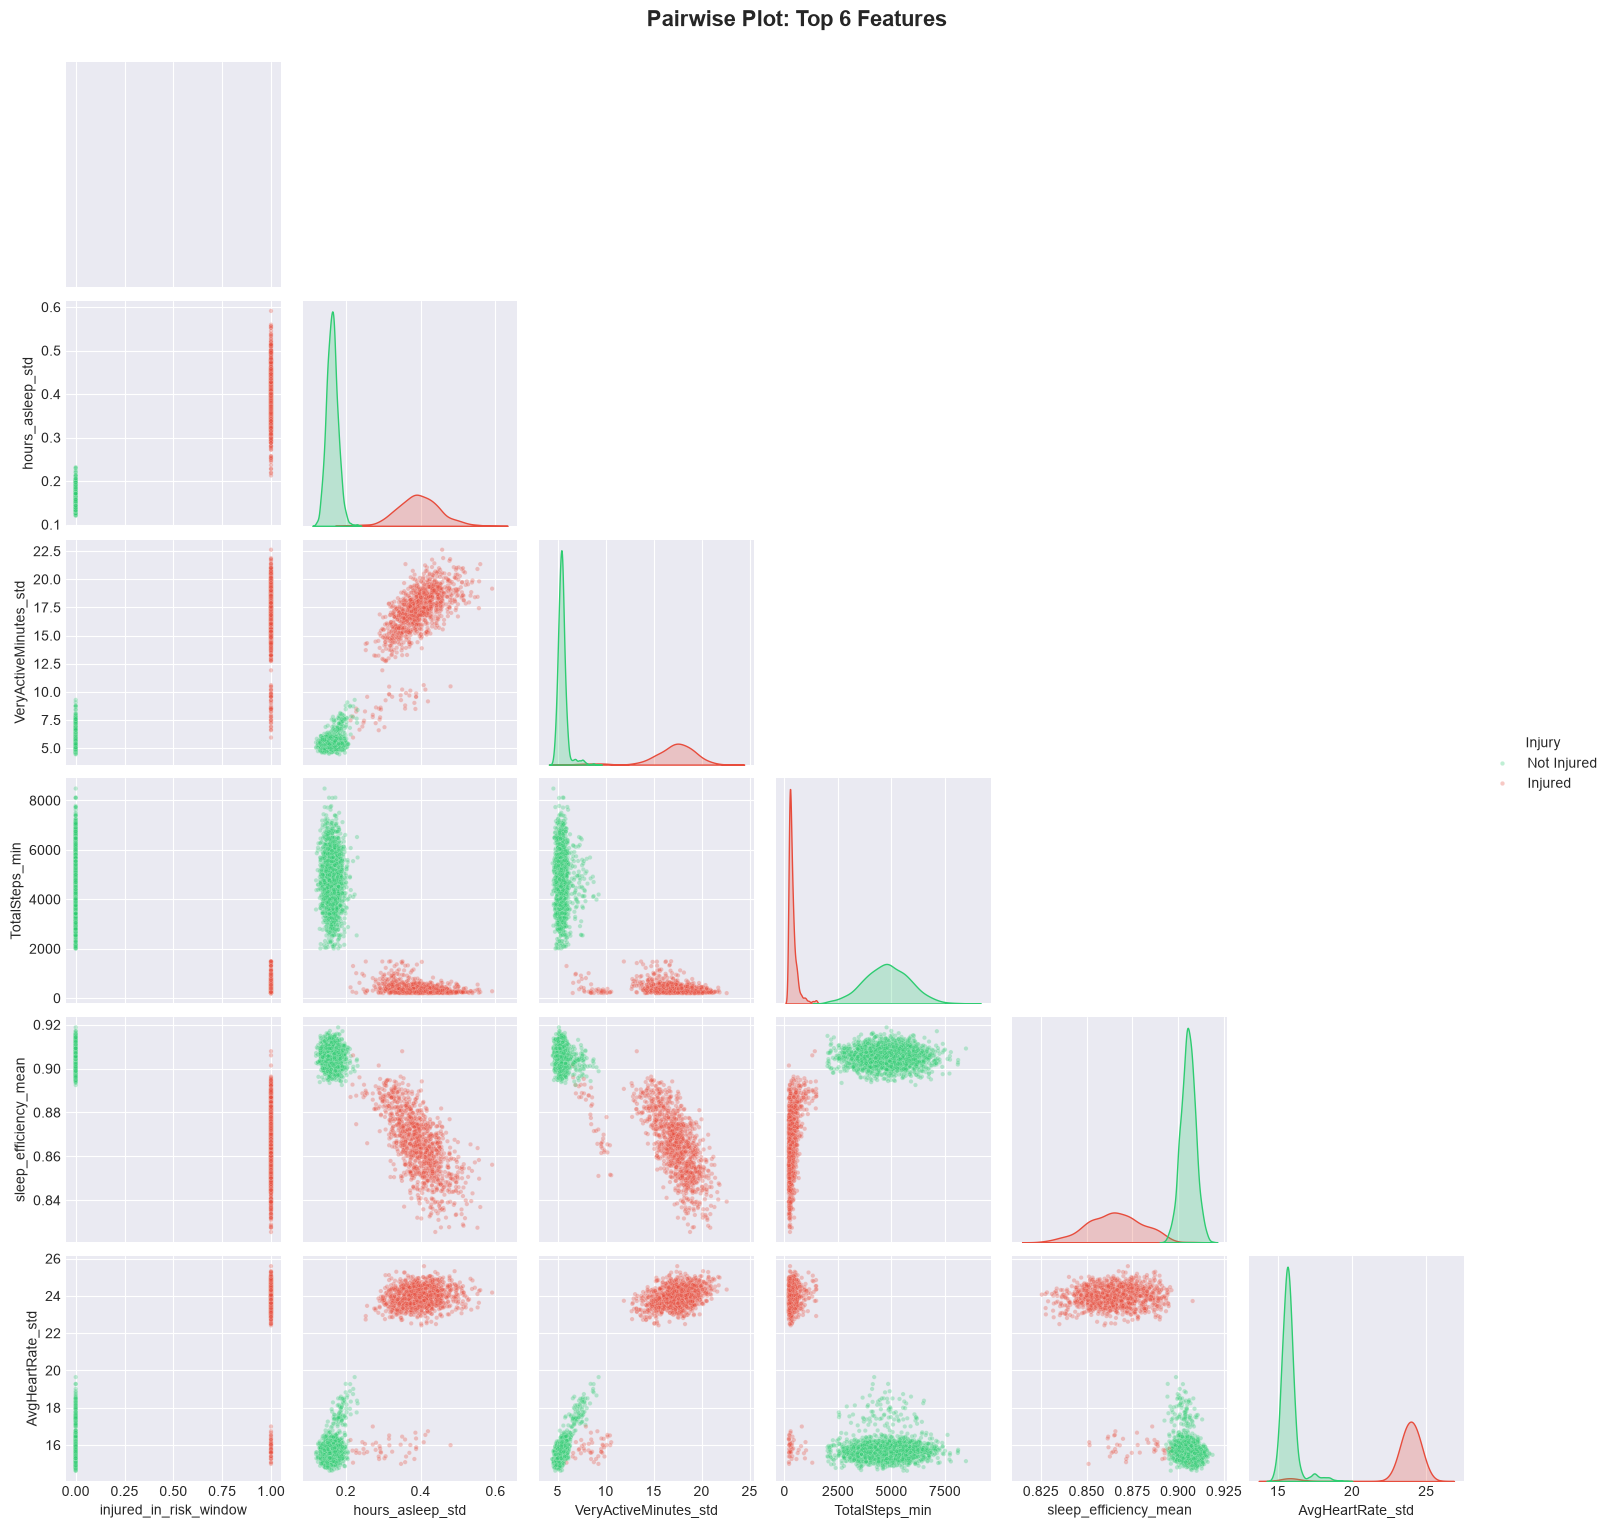

In [34]:
# Pair plot of top 6 features
top6 = combined_ranking['feature'].head(6).tolist()
pair_data = X_imputed[top6].copy()
pair_data['Injury'] = pd.Categorical(y).rename_categories({0: 'Not Injured', 1: 'Injured'})

g = sns.pairplot(pair_data, hue='Injury', palette={'Not Injured': '#2ecc71', 'Injured': '#e74c3c'},
                plot_kws={'alpha': 0.3, 's': 10}, diag_kind='kde', corner=True)
g.figure.suptitle('Pairwise Plot: Top 6 Features', fontsize=16, fontweight='bold', y=1.02)
plt.show()

---
## 📋 13. Missing Data Analysis
---

KeyError: 'ts_session_id'

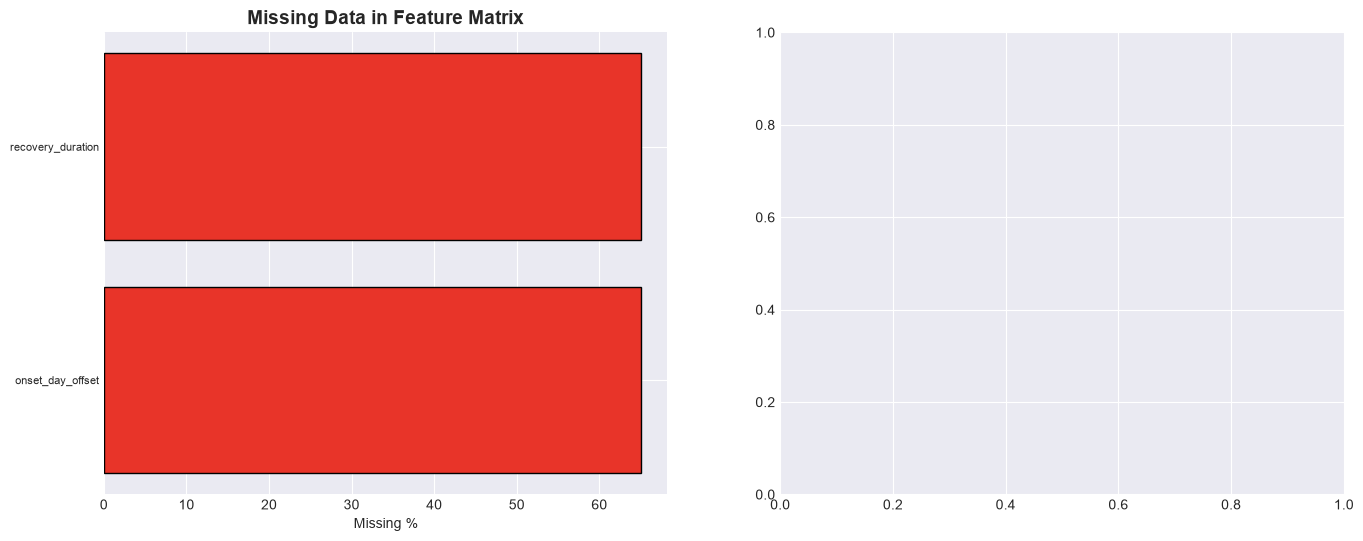

In [35]:
# Missing data patterns across datasets
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature matrix missingness
missing_pct = (feature_matrix.isnull().sum() / len(feature_matrix) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct) > 0:
    axes[0].barh(range(len(missing_pct)), missing_pct.values,
                color=plt.cm.Reds(missing_pct.values / 100), edgecolor='black')
    axes[0].set_yticks(range(len(missing_pct)))
    axes[0].set_yticklabels(missing_pct.index, fontsize=8)
    axes[0].set_xlabel('Missing %')
    axes[0].set_title('Missing Data in Feature Matrix', fontsize=14, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'No missing data!', ha='center', va='center', fontsize=14)
    axes[0].set_title('Missing Data in Feature Matrix', fontsize=14, fontweight='bold')

# Data coverage per athlete (how many data sources each athlete has)
coverage = pd.DataFrame({'athlete_id': feature_matrix['athlete_id']})
coverage['has_daily'] = feature_matrix['TotalSteps_mean'].notna().astype(int)
coverage['has_sleep'] = feature_matrix['hours_asleep_mean'].notna().astype(int)
coverage['has_hr'] = feature_matrix['AvgHeartRate_mean'].notna().astype(int)
coverage['has_training'] = feature_matrix['ts_session_id'].notna().astype(int)
coverage['total_sources'] = coverage[['has_daily', 'has_sleep', 'has_hr', 'has_training']].sum(axis=1)

coverage_dist = coverage['total_sources'].value_counts().sort_index()
axes[1].bar(coverage_dist.index, coverage_dist.values, color='#3498db', edgecolor='black')
axes[1].set_xlabel('Number of Data Sources Available')
axes[1].set_ylabel('Number of Athletes')
axes[1].set_title('Data Source Coverage per Athlete', fontsize=14, fontweight='bold')
for i, (x, v) in enumerate(zip(coverage_dist.index, coverage_dist.values)):
    axes[1].text(x, v + 5, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

---
## 📝 14. EDA Summary & Key Findings
---

In [ ]:
print('=' * 70)
print('📝 EDA SUMMARY & KEY FINDINGS')
print('=' * 70)

print(f"""
1. TARGET DISTRIBUTION:
   - Injury rate: {injury_counts[1] / len(train_labels) * 100:.1f}%
   - Class balance: {injury_counts[0]} not injured vs {injury_counts[1]} injured
   - Onset day offset: mean={injured['onset_day_offset'].mean():.1f}, range=[{injured['onset_day_offset'].min()}, {injured['onset_day_offset'].max()}]
   - Recovery duration: mean={injured['recovery_duration'].mean():.1f}, range=[{injured['recovery_duration'].min()}, {injured['recovery_duration'].max()}]

2. SIGNIFICANT FEATURES:
   - {stat_results['significant_mw'].sum()} features show statistically significant
     differences between injured and not-injured groups
   
3. TOP FEATURES (by combined ranking — Pearson + MI + RF):
""")

for i, row in combined_ranking.head(10).iterrows():
    print(f"   {combined_ranking.index.get_loc(i)+1:2d}. {row['feature']:35s} (avg rank: {row['avg_rank']:.1f})")

print(f"""
4. KEY OBSERVATIONS:
   - Prior season injury count is a strong predictor of future injury
   - Training load (total hours, session count) shows signal
   - Heart rate variability & resting HR differ between groups
   - Sleep patterns (efficiency, variability) are informative
   - Activity variability (std of daily metrics) may signal overtraining
   - ACWR (Acute:Chronic Workload Ratio) captures training load dynamics
   
5. MODELING RECOMMENDATIONS:
   - Use all data sources (daily, hourly, sleep, weight, training, metadata)
   - Engineer time-series features: trends, variability, ratios
   - Handle class imbalance (SMOTE, class weights, threshold tuning)
   - Consider sport-specific models or sport as key feature
   - Use cross-validation to avoid overfitting
""")
print('=' * 70)